<a href="https://colab.research.google.com/github/Protmdd/BD_OECE_PROYECTO_DM/blob/main/ENTREGA_3_Proyecto_DM_OECE_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##GRUPO DIAMOND FINDERS ©

INTEGRANTES:

*Gianella Silvestre Nina   
*Andre de la Fuente   
*Luis Atto Pintado


---



**INDICE**

*1. Problema, usuario y objetivo de análisis

*2. Fuentes de datos y unidad de análisis

*3. Diagnóstico preliminar

*4. Código central

• carga de datos;
• inspección de las fuentes;
• revisión de duplicados;
• validación de las claves;
• integración de las fuentes


*5. Visualizaciones iniciales y hallazgos

*6. Próximos pasos


---




**1. Problema, usuario y objetivo de análisis**

---



TITULO: **Segmentación de proveedores en contrataciones de municipalidades provinciales del Perú según patrones de participación y adjudicación, 2021–2025**

### Problema

Las empresas y proveedores que participan en las contrataciones de las municipalidades provinciales del Perú presentan comportamientos heterogéneos. Algunos participan de manera ocasional, mientras que otros presentan una participación recurrente, obtienen múltiples adjudicaciones, manejan mayores montos contratados o participan en diferentes territorios y rubros.

Sin embargo, la información registrada en el SEACE se encuentra distribuida entre múltiples procesos de contratación, ofertantes y adjudicaciones, lo que dificulta identificar de manera directa los diferentes perfiles de proveedores que participan en este mercado.

Por ello, se busca transformar los registros individuales de contratación en una visión agregada a nivel de proveedor, permitiendo analizar su comportamiento durante el periodo 2021–2025 e identificar grupos de proveedores con características similares.

### Usuario del análisis

El principal usuario del análisis es el **OECE**, y de manera complementaria las entidades públicas responsables de la gestión de contrataciones.

Los resultados pueden servir para comprender mejor la composición y comportamiento del mercado de proveedores, identificar perfiles diferenciados y generar información que contribuya al monitoreo y análisis de las contrataciones públicas.

### Objetivo general

**Identificar y caracterizar segmentos naturales de proveedores que participan en las contrataciones de municipalidades provinciales del Perú durante 2021–2025, utilizando sus patrones de participación, adjudicación, escala económica y alcance territorial.**

### Objetivos específicos

1. **Construir un perfil agregado por proveedor** a partir de los registros de participación y adjudicación de las contrataciones.

2. **Identificar patrones de comportamiento** relacionados con frecuencia de participación, tasa de adjudicación, monto adjudicado, diversificación territorial y participación en consorcios.

3. **Aplicar técnicas de clustering** para identificar grupos de proveedores con características similares.

4. **Caracterizar y comparar los segmentos encontrados**, identificando las variables que diferencian a cada perfil.

5. **Analizar variables complementarias**, como las penalidades, para determinar si existen diferencias entre los segmentos identificados.

### Pregunta principal

**¿Qué segmentos naturales de proveedores pueden identificarse en las contrataciones de municipalidades provinciales del Perú durante 2021–2025 y qué características definen a cada perfil?**



---


**2. Fuentes de datos y unidad de análisis**


---



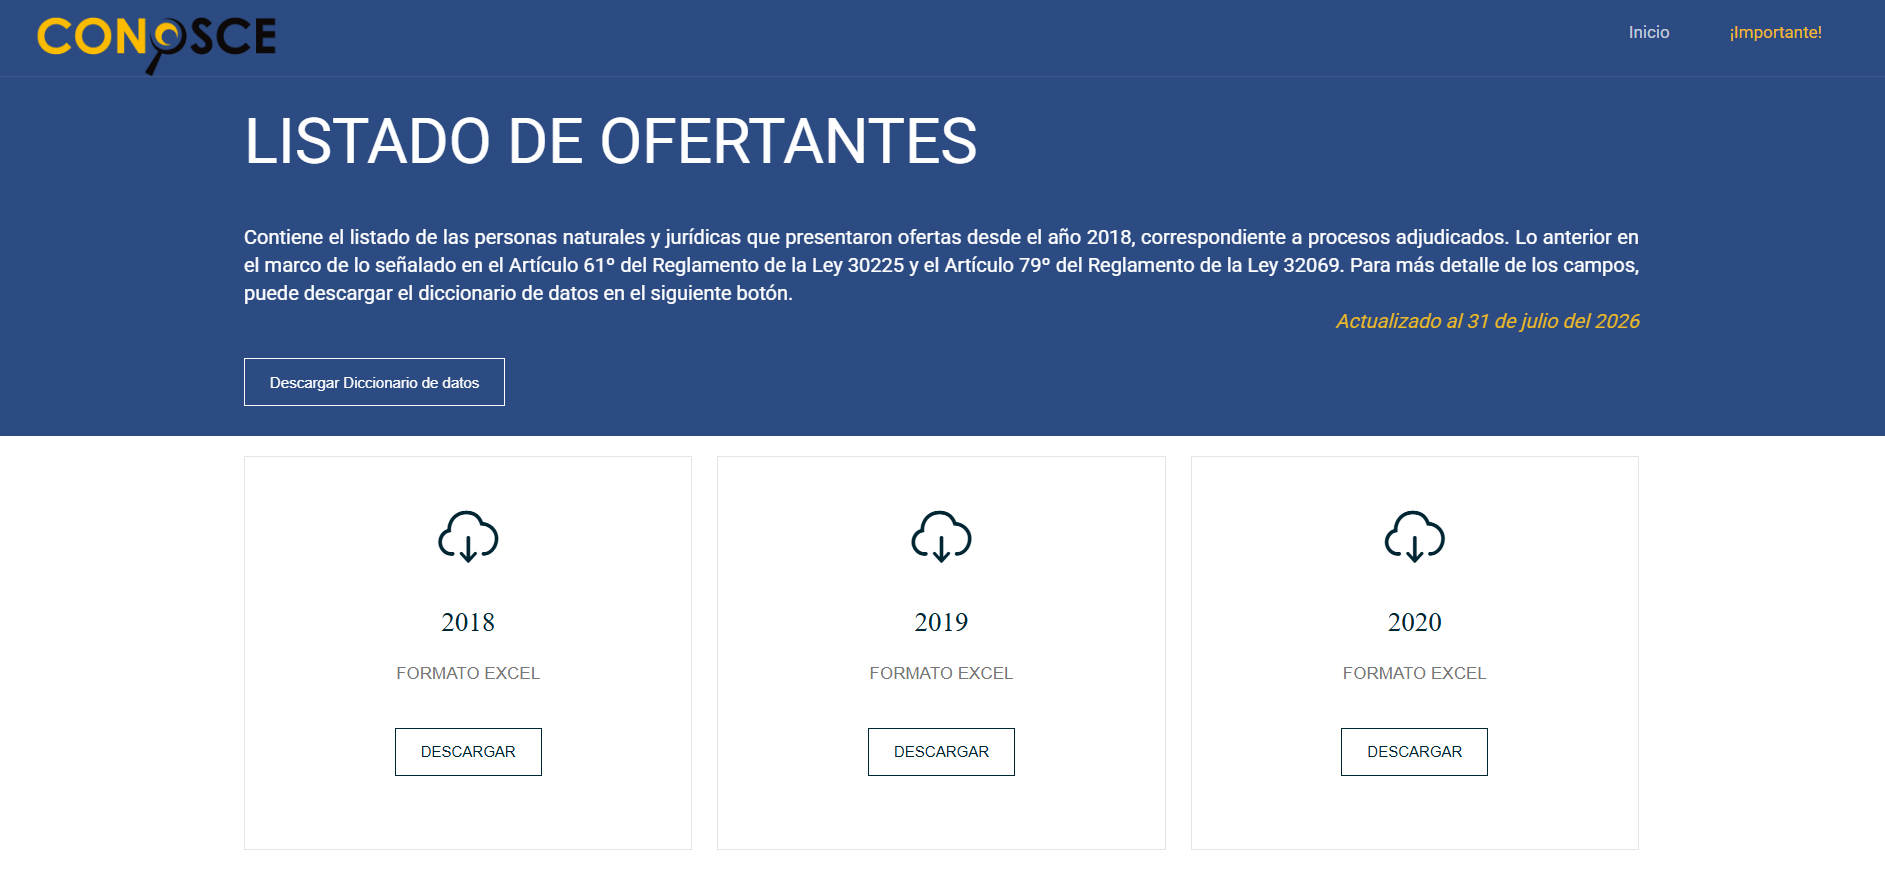

### Unidad de análisis

La **unidad de análisis es el proveedor**, considerando principalmente empresas y otros proveedores que participan en contrataciones de municipalidades provinciales del Perú.

Cada proveedor constituye una observación en el dataset final. Para cada uno se agregan sus características y comportamiento durante el periodo 2021–2025, incluyendo variables como número de convocatorias en las que participó, adjudicaciones obtenidas, tasa de adjudicación, monto total adjudicado, número de rubros, alcance territorial y participación en consorcios.

De esta manera, el análisis no busca segmentar procesos de contratación individuales, sino **segmentar proveedores según sus patrones agregados de participación y adjudicación**.


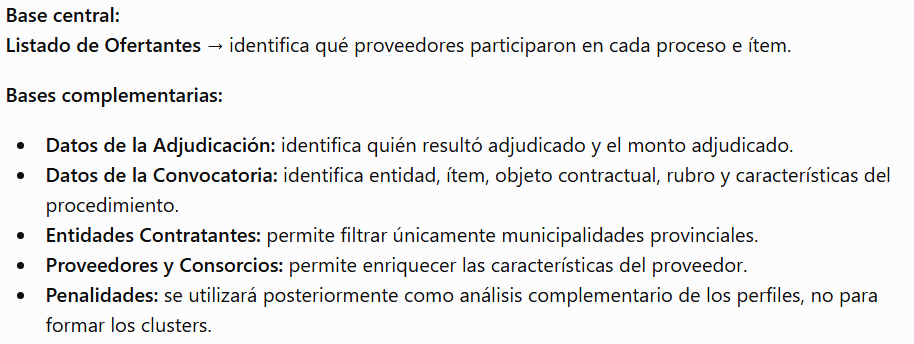

In [ ]:
# ============================================================
# DESCARGAR DATOS DESDE GITHUB
# ============================================================
import os
if not os.path.exists("/content/BD_OECE_PROYECTO_DM"):
    !git clone https://github.com/Protmdd/BD_OECE_PROYECTO_DM.git

try:
    import python_calamine
except ImportError:
    !pip install -q python-calamine

# ============================================================
# LECTURA Y CONCATENACIÓN MULTI-AÑO
# ============================================================
import glob, warnings, unicodedata, re, json
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

BASE = "/content/BD_OECE_PROYECTO_DM/Bases de Datos Proyecto DM"
CACHE = "/content/cache"
OUTPUT_DIR = "/content"
os.makedirs(CACHE, exist_ok=True)

# ------------------------------------------------------------
# 0) Normalizador de nombres de columna
# ------------------------------------------------------------
def norm_cols(df):
    def limpia(c):
        c = str(c).strip()
        c = unicodedata.normalize('NFKD', c).encode('ascii', 'ignore').decode('ascii')
        c = c.lower()
        c = c.replace('/', '_').replace('-', '_')
        c = '_'.join(c.split())
        c = ''.join(ch for ch in c if ch.isalnum() or ch == '_')
        return c.strip('_')
    df = df.copy()
    df.columns = [limpia(c) for c in df.columns]
    df = df.loc[:, ~df.columns.str.startswith('unnamed')]
    df = df.dropna(axis=1, how='all')
    df = df.rename(columns={'ano': 'anio', 'ao': 'anio'})

    # antes se descartaban columnas duplicadas sin avisar (dos columnas de origen
    # distinto pueden terminar con el mismo nombre tras normalizar tildes/espacios)
    dup_mask = df.columns.duplicated()
    if dup_mask.any():
        print(f"  ⚠ columnas duplicadas tras normalizar nombres, se descarta la repetida: {sorted(set(df.columns[dup_mask]))}")
    df = df.loc[:, ~dup_mask]
    return df


# ------------------------------------------------------------
# 0.1) Deduplicación por llave de integración, con reporte explícito
#      (se usa antes de cada merge para no inflar filas silenciosamente)
# ------------------------------------------------------------
def dedup_por_llave(df, llave, nombre):
    dup_mask = df.duplicated(subset=llave, keep=False)
    n_filas_dup = dup_mask.sum()
    if n_filas_dup == 0:
        print(f"  {nombre}: llave {llave} única, sin duplicados.")
        return df

    n_llaves_dup = df.loc[dup_mask, llave].drop_duplicates().shape[0]
    print(f"  {nombre}: {n_llaves_dup:,} llaves con más de un registro ({n_filas_dup:,} filas afectadas).")

    # si las filas repetidas son 100% idénticas en todas las columnas, es un
    # duplicado de registro real y se puede colapsar sin perder información
    n_antes = len(df)
    df = df.drop_duplicates()
    print(f"    filas colapsadas por ser duplicado exacto: {n_antes - len(df):,}")

    # lo que sigue con la misma llave pero contenido distinto no se puede resolver
    # automáticamente sin perder información -> se deja explícito para revisión manual,
    # y el merge posterior SÍ va a multiplicar esas filas si no se corrige a mano
    restantes = df.duplicated(subset=llave, keep=False).sum()
    if restantes > 0:
        print(f"    ⚠ quedan {restantes:,} filas con llave repetida pero contenido distinto -> revisar manualmente antes del merge.")
    return df


# ------------------------------------------------------------
# 1) Lector multi-año de Excel con cache en Parquet
#    (el cache ahora se invalida si la lista de archivos fuente cambió,
#    no solo si existe un .parquet con ese nombre)
# ------------------------------------------------------------
def leer_multianio(patron, base=BASE, agregar_anio=True, usar_cache=True):
    cache_file = os.path.join(CACHE, patron.replace('*', '').replace('.xlsx', '') + '.parquet')
    meta_file = cache_file.replace('.parquet', '_meta.json')

    files = sorted(glob.glob(os.path.join(base, patron)))
    archivos_actuales = sorted(os.path.basename(f) for f in files)

    if usar_cache and os.path.exists(cache_file) and os.path.exists(meta_file):
        with open(meta_file) as fh:
            meta_previo = json.load(fh)
        if meta_previo.get('archivos') == archivos_actuales:
            out = pd.read_parquet(cache_file)
            print(f"  ⚡ leído desde cache: {cache_file} -> {out.shape[0]:,} filas x {out.shape[1]} cols\n")
            return out
        else:
            print(f"  ⚠ cache desactualizado para '{patron}' (cambió la lista de archivos fuente), releyendo...")

    if not files:
        print(f"  Sin archivos para el patrón: {patron}")
        return pd.DataFrame()

    dfs, sets_cols = [], []
    for f in files:
        nombre = os.path.basename(f)
        df = norm_cols(pd.read_excel(f, engine='calamine'))

        if agregar_anio:
            digits = ''.join(ch for ch in nombre if ch.isdigit())
            df['anio_archivo'] = digits[:4] if len(digits) >= 4 else None
            df['archivo_origen'] = nombre

        sets_cols.append(set(df.columns))
        print(f"  ✔ {nombre:<48} -> {df.shape[0]:>9,} filas | {df.shape[1]:>2} cols")
        dfs.append(df)

    comunes, todas = set.intersection(*sets_cols), set.union(*sets_cols)
    if todas - comunes:
        print(f"  Columnas no presentes en todos los años: {sorted(todas - comunes)}")

    out = pd.concat(dfs, ignore_index=True, sort=False)
    print(f"  ➜ CONCATENADO: {out.shape[0]:,} filas x {out.shape[1]} cols\n")

    if usar_cache:
        out.to_parquet(cache_file)
        with open(meta_file, 'w') as fh:
            json.dump({'archivos': archivos_actuales}, fh)

    return out


# ------------------------------------------------------------
# 2) Lector de PENALIDADES (vectorizado, con reparación solo para filas rotas)
#    Estructura: ID CONTRATO|RUC CONTRATISTA|TIPO PENALIDAD|OBJETO CONTRATO|
#                ENTIDAD CONTRATANTE|FECHA PENALIDAD|DESCRIPCION/MOTIVO|MONTO
# ------------------------------------------------------------
def leer_penalidades(nombre="penalidades.csv", base=BASE, sep='|',
                     col_texto=6, encodings=('utf-8', 'utf-8-sig', 'latin-1'),
                     usar_cache=True):
    cache_file = os.path.join(CACHE, 'penalidades.parquet')
    if usar_cache and os.path.exists(cache_file):
        df = pd.read_parquet(cache_file)
        print(f"  ⚡ leído desde cache: {cache_file} -> {df.shape[0]:,} filas | {df.shape[1]} cols\n")
        return df

    ruta = os.path.join(base, nombre)

    for enc in encodings:
        try:
            with open(ruta, 'r', encoding=enc) as fh:
                lineas = fh.read().splitlines()
            break
        except UnicodeDecodeError:
            continue

    header = [h.strip() for h in lineas[0].split(sep)]
    ncol = len(header)
    body = pd.Series([l for l in lineas[1:] if l.strip()])

    # separa filas bien formadas (vectorizado) de las rotas (loop solo ahí)
    n_pipes = body.str.count(re.escape(sep))
    ok_mask = n_pipes == (ncol - 1)

    df_ok = body[ok_mask].str.split(sep, expand=True)
    df_ok.columns = header
    df_ok['fila_incompleta'] = False

    # OJO: las filas de este bloque NO se descartan del dataset final, se
    # rellenan con None y de todas formas se concatenan (df_mal + df_ok).
    # 'incompletas_rellenadas' refleja eso; se agrega además una columna
    # 'fila_incompleta' para poder filtrarlas explícitamente más adelante
    # si se decide que no son confiables.
    filas_mal, reparadas, incompletas_rellenadas = [], 0, 0
    for ln in body[~ok_mask]:
        p = ln.split(sep)
        if len(p) > ncol:
            n_extra = len(p) - ncol
            p = (p[:col_texto]
                 + [sep.join(p[col_texto: col_texto + 1 + n_extra])]
                 + p[col_texto + 1 + n_extra:])
            reparadas += 1
        else:
            p = p + [None] * (ncol - len(p))
            incompletas_rellenadas += 1
        filas_mal.append(p)

    df_mal = pd.DataFrame(filas_mal, columns=header) if filas_mal else pd.DataFrame(columns=header)
    df_mal['fila_incompleta'] = True

    df = pd.concat([df_ok, df_mal], ignore_index=True)
    cols_texto = [c for c in df.columns if c != 'fila_incompleta']
    df[cols_texto] = df[cols_texto].apply(lambda c: c.str.strip() if c.dtype == 'object' else c)
    # norm_cols descarta columnas duplicadas por nombre; fila_incompleta ya tiene nombre único
    df = norm_cols(df)

    # tipos
    df['monto'] = pd.to_numeric(df['monto'], errors='coerce')
    df['fecha_penalidad'] = pd.to_datetime(df['fecha_penalidad'],
                                           format='%d/%m/%y', errors='coerce')
    df['ruc_contratista'] = (df['ruc_contratista'].astype(str)
                             .str.replace(r'\.0$', '', regex=True).str.strip())

    print(f"  ✔ {nombre} (enc={enc}) -> {df.shape[0]:,} filas | {df.shape[1]} cols")
    print(f"     filas reparadas (| extra): {reparadas:,} | filas incompletas rellenadas con None: {incompletas_rellenadas:,}")
    print(f"     columnas: {list(df.columns)}\n")

    if usar_cache:
        df.to_parquet(cache_file)

    return df


# ------------------------------------------------------------
# 3) Lector de CSV simple (entidades)
# ------------------------------------------------------------
def leer_csv(nombre, base=BASE, sep='|'):
    ruta = os.path.join(base, nombre)
    for enc in ('utf-8', 'utf-8-sig', 'latin-1'):
        try:
            df = norm_cols(pd.read_csv(ruta, sep=sep, encoding=enc,
                                       engine='python', on_bad_lines='skip', dtype=str))
            print(f"  ✔ {nombre} (enc={enc}) -> {df.shape[0]:,} filas | {df.shape[1]} cols\n")
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError(f"No se pudo leer {nombre}")


# ============================================================
# GENERACIÓN DE LOS DATAFRAMES
# ============================================================
print("📂 ADJUDICACIONES:");  df_adj  = leer_multianio("CONOSCE_ADJUDICACIONES*.xlsx")
print("📂 POSTORES:");        df_post = leer_multianio("CONOSCE_POSTOR*.xlsx")
print("📂 CONSORCIOS:");      df_cons = leer_multianio("CONOSCE_CONSORCIO*.xlsx")
print("📂 CONVOCATORIAS:");   df_conv = leer_multianio("CONOSCE_CONVOCATORIAS*.xlsx")
print("📂 ENTIDADES:");       df_ent  = leer_csv("entidades_contratantes.csv")
print("📂 PENALIDADES:");     df_pen  = leer_penalidades("penalidades.csv")


# ============================================================
# RESUMEN + VERIFICACIÓN
# ============================================================
dfs = {'df_adj': df_adj, 'df_post': df_post, 'df_cons': df_cons,
       'df_conv': df_conv, 'df_ent': df_ent, 'df_pen': df_pen}

resumen_dfs = pd.DataFrame([{'DataFrame': k,
                             'Filas': v.shape[0],
                             'Columnas': v.shape[1],
                             'MB': round(v.memory_usage(deep=True).sum() / 1e6, 1)}
                            for k, v in dfs.items()])

print("=" * 70)
print("RESUMEN DE DATAFRAMES GENERADOS")
print("=" * 70)
print(resumen_dfs.to_string(index=False))

for k, v in dfs.items():
    print(f"\n{k} ({v.shape[0]:,} x {v.shape[1]}):\n  {list(v.columns)}")

for nombre, d in [('ADJUDICACIONES', df_adj), ('POSTORES', df_post),
                  ('CONSORCIOS', df_cons), ('CONVOCATORIAS', df_conv)]:
    if 'anio_archivo' in d.columns:
        print(f"\n{nombre} — registros por año:")
        print(d['anio_archivo'].value_counts().sort_index().to_string())


Cloning into 'BD_OECE_PROYECTO_DM'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 29 (delta 1), reused 25 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 221.65 KiB | 9.24 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Filtering content: 100% (22/22), 237.44 MiB | 18.12 MiB/s, done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 8.4 MB/s eta 0:00:00
📂 ADJUDICACIONES:
  ✔ CONOSCE_ADJUDICACIONES2021_0.xlsx                ->    58,721 filas | 27 cols
  ✔ CONOSCE_ADJUDICACIONES2022_0.xlsx                ->    68,153 filas | 27 cols
  ✔ CONOSCE_ADJUDICACIONES2023_0.xlsx                ->    68,464 filas | 27 cols
  ✔ CONOSCE_ADJUDICACIONES2024_0.xlsx                ->    67,466 filas | 27 cols
  ✔ CONOSCE_ADJUDICACIONES2025_0.xlsx                ->    63,966 filas | 27 cols
  ➜ CONCATENADO: 326,770 filas x 27 cols

📂 POSTORES:
  ✔ CONOSCE_POSTOR2021_0.xlsx

**POSIBLE LLAVE DE INTEGRACIÓN.**

**Columnas en df_post (Listado de Ofertantes):**

['codigo_convocatoria', 'fechaconvocatoria', 'n_item', 'ruc_codigo_postor', 'postor', 'fecha_presentacion_propuesta', 'anio_archivo', 'archivo_origen']


--- **Columnas comunes con otros DataFrames** ---

df_post y df_adj (Adjudicaciones): ['anio_archivo', 'archivo_origen', 'n_item']

df_post y df_cons (Consorcios): ['anio_archivo', 'archivo_origen']

df_post y df_conv (Convocatorias): ['anio_archivo', 'archivo_origen', 'n_item']

df_post y df_ent (Entidades): []

df_post y df_pen (Penalidades): []


Análisis de Llaves de Integración Sugeridas:
  - `codigo_convocatoria`: Clave para integrar `df_post` con `df_adj` y `df_conv`.
  - `ruc_codigo_postor` (en `df_post`) / `ruc_contratista` (en `df_pen`): Podrían ser RUCs de proveedores/contratistas.
  - `anio_archivo`: Útil para integrar por año, aunque ya está presente en casi todos los DataFrames.




---



**3. Diagnóstico preliminar**

---



### Resumen Detallado por Fuente de Datos
A continuación, se presenta un resumen exhaustivo para cada DataFrame, que incluye:
*   **Dimensiones:** Número de filas y columnas.
*   **Tipos de Datos:** El tipo de dato inferido por Pandas para cada columna.
*   **Valores Distintos:** El número de valores únicos en cada columna.
*   **Ejemplos de Valores:** Las primeras 5 filas del DataFrame para una vista rápida de los datos.

In [ ]:
def summarize_dataframe_full(df, name):
    print(f"\n{'='*70}\nRESUMEN COMPLETO PARA: {name}\n{'='*70}")

    # Dimensiones
    print(f"\nDimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")

    # Tipos de Datos
    print("\nTipos de Datos:")
    display(df.dtypes.to_frame(name='Tipo de Dato'))

    # Valores Distintos
    print("\nValores Distintos por Columna:")
    display(df.nunique().to_frame(name='Valores Únicos'))

    # Ejemplos de Valores
    print("\nEjemplos de Valores (primeras 5 filas):")
    display(df.head())


# Aplicar la función a cada DataFrame
for name, df in dfs.items():
    summarize_dataframe_full(df, name)


RESUMEN COMPLETO PARA: df_adj

Dimensiones: 326,770 filas x 27 columnas

Tipos de Datos:


,Tipo de Dato
codigoentidad,int64
entidad_ruc,int64
entidad,object
tipoentidad,object
entidad_departamento,object
codigoconvocatoria,int64
objetocontractual,object
tipoprocesoseleccion,object
proceso,object
descripcion_proceso,object



Valores Distintos por Columna:


,Valores Únicos
codigoentidad,3044
entidad_ruc,3044
entidad,3044
tipoentidad,5
entidad_departamento,25
codigoconvocatoria,286572
objetocontractual,4
tipoprocesoseleccion,43
proceso,259817
descripcion_proceso,273947



Ejemplos de Valores (primeras 5 filas):


...

,Tipo de Dato
id_contrato,object
ruc_contratista,object
tipo_penalidad,object
objeto_contrato,object
entidad_contratante,object
fecha_penalidad,datetime64[ns]
descripcion_motivo,object
monto,float64
fila_incompleta,bool



Valores Distintos por Columna:


,Valores Únicos
id_contrato,5125
ruc_contratista,3233
tipo_penalidad,2
objeto_contrato,4
entidad_contratante,628
fecha_penalidad,1581
descripcion_motivo,8361
monto,1938
fila_incompleta,2



Ejemplos de Valores (primeras 5 filas):


,id_contrato,ruc_contratista,tipo_penalidad,objeto_contrato,entidad_contratante,fecha_penalidad,descripcion_motivo,monto,fila_incompleta
0,2255476,20536426168,Otra Penalidad,Servicio,PROYECTO ESPECIAL DE INVERSION PUBLICA ESCUELA...,2026-03-10,PENALIDAD POR INCIDENCIA ADMINISTRATIVA ASOCIA...,220.0,False
1,2330522,20553404631,Por Mora,Servicio,PROYECTO ESPECIAL DE INVERSION PUBLICA ESCUELA...,2025-08-05,SE REGISTRA LA APLICACION DE PENALIDAD EN FUNC...,NaN,False
2,2330522,20553404631,Por Mora,Servicio,PROYECTO ESPECIAL DE INVERSION PUBLICA ESCUELA...,2025-08-27,SE REGISTRA LA APLICACION DE PENALIDAD EN FUNC...,NaN,False
3,2320073,20536426168,Otra Penalidad,Servicio,PROYECTO ESPECIAL DE INVERSION PUBLICA ESCUELA...,2026-03-25,PENALIDAD POR INCIDENCIA ADMINISTRATIVA ASOCIA...,220.0,False
4,2234695,10283047682,Otra Penalidad,Consultoría de Obra,MUNICIPALIDAD DISTRITAL DE MEGANTONI,2025-02-15,APLICACION DE PENALIDAD,2575.0,False




---


**4. CODIGO CENTRAL**

---



### Detección Específica de Problemas de Calidad de Datos

### 4.1 Valores Faltantes (Missing Values)

In [ ]:
print("\n--- df_adj: Adjudicaciones ---")
missing_adj = df_adj.isnull().sum()
missing_adj = missing_adj[missing_adj > 0]
if not missing_adj.empty:
    missing_adj_pct = (missing_adj / len(df_adj)) * 100
    missing_adj_df = pd.DataFrame({'Count': missing_adj, 'Percentage': missing_adj_pct})
    display(missing_adj_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_adj.")

print("\n--- df_post: Postores ---")
missing_post = df_post.isnull().sum()
missing_post = missing_post[missing_post > 0]
if not missing_post.empty:
    missing_post_pct = (missing_post / len(df_post)) * 100
    missing_post_df = pd.DataFrame({'Count': missing_post, 'Percentage': missing_post_pct})
    display(missing_post_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_post.")

print("\n--- df_cons: Consorcios ---")
missing_cons = df_cons.isnull().sum()
missing_cons = missing_cons[missing_cons > 0]
if not missing_cons.empty:
    missing_cons_pct = (missing_cons / len(df_cons)) * 100
    missing_cons_df = pd.DataFrame({'Count': missing_cons, 'Percentage': missing_cons_pct})
    display(missing_cons_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_cons.")

print("\n--- df_conv: Convocatorias ---")
missing_conv = df_conv.isnull().sum()
missing_conv = missing_conv[missing_conv > 0]
if not missing_conv.empty:
    missing_conv_pct = (missing_conv / len(df_conv)) * 100
    missing_conv_df = pd.DataFrame({'Count': missing_conv, 'Percentage': missing_conv_pct})
    display(missing_conv_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_conv.")

print("\n--- df_ent: Entidades ---")
missing_ent = df_ent.isnull().sum()
missing_ent = missing_ent[missing_ent > 0]
if not missing_ent.empty:
    missing_ent_pct = (missing_ent / len(df_ent)) * 100
    missing_ent_df = pd.DataFrame({'Count': missing_ent, 'Percentage': missing_ent_pct})
    display(missing_ent_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_ent.")

print("\n--- df_pen: Penalidades ---")
missing_pen = df_pen.isnull().sum()
missing_pen = missing_pen[missing_pen > 0]
if not missing_pen.empty:
    missing_pen_pct = (missing_pen / len(df_pen)) * 100
    missing_pen_df = pd.DataFrame({'Count': missing_pen, 'Percentage': missing_pen_pct})
    display(missing_pen_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_pen.")


--- df_adj: Adjudicaciones ---


,Count,Percentage
fecha_consentimiento_bp,2914,0.891759
departamento_item,1657,0.507084
fecha_buenapro,80,0.024482
monto_referencial_item_soles,3,0.000918
tipo_proveedor,1,0.000306



--- df_post: Postores ---
No hay valores faltantes en df_post.

--- df_cons: Consorcios ---
No hay valores faltantes en df_cons.

--- df_conv: Convocatorias ---


,Count,Percentage
fechaintegracionbases,124256,38.265583
codigoitem,49587,15.270695
itemcubso,49587,15.270695
fechapresentacionpropuesta,39562,12.183420
distrito_item,1653,0.509054
departamento_item,1653,0.509054
provincia_item,1653,0.509054
sistema_contratacion,68,0.020941



--- df_ent: Entidades ---


,Count,Percentage
codigo_siaf,352,10.466845



--- df_pen: Penalidades ---


,Count,Percentage
monto,7332,52.375170
tipo_penalidad,1,0.007143
objeto_contrato,1,0.007143
entidad_contratante,1,0.007143
fecha_penalidad,1,0.007143
descripcion_motivo,1,0.007143


### 4.2 Duplicados

In [ ]:
print("### Detección de Filas Duplicadas ###\n")

# Apply necessary renames for duplication check
# These renames are crucial because subsequent lines rely on these new column names.
# Based on the kernel state, df_conv, df_adj, and df_post still have their original column names.
df_conv = df_conv.rename(columns={'codigoconvocatoria': 'codigo_convocatoria'})
df_adj = df_adj.rename(columns={'codigoconvocatoria': 'codigo_convocatoria'})
df_post = df_post.rename(columns={'ruc_codigo_postor': 'ruc_proveedor'})


for name, df in dfs.items():
    total_duplicados = df.duplicated().sum()
    if total_duplicados > 0:
        print(f"DataFrame '{name}': {total_duplicados:,} filas completamente duplicadas.")
    else:
        print(f"DataFrame '{name}': No se encontraron filas completamente duplicadas.")

# Penalidades: los duplicados exactos SÍ se eliminan aquí, antes de cualquier
# groupby, para no contar la misma penalidad (y su monto) más de una vez.
n_dup_pen = df_pen.duplicated().sum()
if n_dup_pen > 0:
    print(f"\ndf_pen: eliminando {n_dup_pen:,} filas completamente duplicadas antes de usarlas en agregaciones.")
    df_pen = df_pen.drop_duplicates().reset_index(drop=True)
    dfs['df_pen'] = df_pen

# Duplicados por llave de integración (no por fila completa). Si aquí aparece
# algo > 0, el merge de la sección de integración va a inflar filas si no se
# resuelve antes (ver dedup_por_llave en la celda de integración Nivel 1).
print("\nDuplicados por llave de integración (antes de mergear):")
print(f"  df_conv por (codigo_convocatoria, n_item): {df_conv.duplicated(['codigo_convocatoria', 'n_item']).sum():,}")
print(f"  df_adj  por (codigo_convocatoria, n_item): {df_adj.duplicated(['codigo_convocatoria', 'n_item']).sum():,}")
print(f"  df_post por (codigo_convocatoria, n_item, ruc_proveedor): {df_post.duplicated(['codigo_convocatoria', 'n_item', 'ruc_proveedor']).sum():,}")

### Detección de Filas Duplicadas ###

DataFrame 'df_adj': No se encontraron filas completamente duplicadas.
DataFrame 'df_post': No se encontraron filas completamente duplicadas.
DataFrame 'df_cons': No se encontraron filas completamente duplicadas.
DataFrame 'df_conv': No se encontraron filas completamente duplicadas.
DataFrame 'df_ent': No se encontraron filas completamente duplicadas.
DataFrame 'df_pen': 367 filas completamente duplicadas.

df_pen: eliminando 367 filas completamente duplicadas antes de usarlas en agregaciones.

Duplicados por llave de integración (antes de mergear):
  df_conv por (codigo_convocatoria, n_item): 0
  df_adj  por (codigo_convocatoria, n_item): 2,050
  df_post por (codigo_convocatoria, n_item, ruc_proveedor): 292


### 4.3 Tipos Incorrectos y Errores de Registro (Coerción a NaN/NaT)

In [ ]:
print("### Detección de Errores de Tipo y Coerción ###\n")
def check_type_coercion(df, df_name):
    # columnas que por su nombre/uso deberían ser numéricas o fecha.
    # 'ruc' se excluye a propósito: el RUC se trata como texto (para no perder
    # ceros a la izquierda, ver celda de estandarización de llaves), así que
    # marcarlo como "error" cuando no es numérico sería un falso positivo.
    cols_esperado_numerico = [c for c in df.columns
                               if any(k in c.lower() for k in ['monto', 'cantidad', 'codigo', 'n_item'])
                               and 'ruc' not in c.lower()]
    cols_esperado_fecha    = [c for c in df.columns if 'fecha' in c.lower()]

    for col in cols_esperado_numerico:
        if pd.api.types.is_numeric_dtype(df[col].dtype):
            continue
        temp_numeric = pd.to_numeric(df[col], errors='coerce')
        numeric_errors = temp_numeric.isnull() & df[col].notnull()
        if numeric_errors.any():
            print(f"DataFrame '{df_name}', Columna '{col}' (Numérico): {numeric_errors.sum():,} valores no numéricos. Ejemplos: {df[col][numeric_errors].head().tolist()}")

    for col in cols_esperado_fecha:
        if pd.api.types.is_datetime64_any_dtype(df[col].dtype):
            continue
        temp_datetime = pd.to_datetime(df[col], errors='coerce')
        datetime_errors = temp_datetime.isnull() & df[col].notnull()
        if datetime_errors.any():
            print(f"DataFrame '{df_name}', Columna '{col}' (Fecha): {datetime_errors.sum():,} valores no-fecha. Ejemplos: {df[col][datetime_errors].head().tolist()}")

for name, df in dfs.items():
    print(f"Analizando DataFrame: {name}")
    check_type_coercion(df, name)
    print("-" * 50)


### Detección de Errores de Tipo y Coerción ###

Analizando DataFrame: df_adj
DataFrame 'df_adj', Columna 'descripcion_item' (Numérico): 326,735 valores no numéricos. Ejemplos: ['SERVICIO DE MANTENIMIENTO PREVENTIVO Y CORRECTIVO DE LA RED DE ENERGIA DE ALIMENTACION PARA LOS SISTEMAS DE AIRE ACONDICIONADO DE LAS 3 UCIS DEL HMC PP-135', 'BOLSA DE POLIETILENO BIODEGRADABLE VERDE DE 75 L', 'SUSCRIPCION A LA BASE DE DATOS E-LIBRO', 'CONTRATACION DE SERVICIO DE CONSULTORIA OBRA PARA LA ELABORACI¿N DE EXPEDIENTE T¿CNICO DEL PROYECTO ¿MEJORAMIENTO Y AMPLIACION DEL SERVICIO EDUCATIVO DE NIVEL INICIAL EN LA INSTITUCION EDUCATIVA N¿ 344 DE LA LOCALIDAD DE TACA, DEL DISTRITO DE CANARIA, PROVINCIA DE VICTOR FAJARDO, DEPARTAMENTO DE AYACUCHO¿', 'ELABORACI¿N DE EXPEDIENTE T¿CNICO:  ¿MEJORAMIENTO Y AMPLIACION DEL SERVICIO EDUCATIVO DEL NIVEL SECUNDARIO DE LA I.E. NUESTRA SE¿ORA DEL CARMEN DEL DISTRITO DE IMPERIAL, PROVINCIA DE CA¿ETE, DEPARTAMENTO DE LIMA¿ CUI N¿ 2338999']
DataFrame 'df_adj', Columna 

### 4.4 Valores Fuera de Rango y Outliers (Valores Atípicos)

In [ ]:
print("### Detección de Outliers (IQR) y Valores Fuera de Rango (Heurístico) ###\n")

def es_columna_id_o_binaria(col, serie):
    """Columnas identificadoras (codigo/ruc/n_item/anio) o binarias 0/1:
    el IQR no tiene interpretación estadística sobre ellas."""
    nombre = col.lower()
    if any(p in nombre for p in ['codigo', 'ruc', 'n_item', 'anio', 'id_']):
        return True
    valores = serie.dropna().unique()
    if len(valores) > 0 and set(valores).issubset({0, 1}):
        return True
    return False

def detect_outliers_and_range(df, df_name):
    print(f"Analizando DataFrame: {df_name}")
    numerical_cols = df.select_dtypes(include=['number']).columns

    for col in numerical_cols:
        if es_columna_id_o_binaria(col, df[col]):
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

        if not outliers.empty:
            # los outliers se reportan como alerta para revisión, no se eliminan
            # automáticamente: un proveedor con montos/participaciones muy altos
            # puede ser un caso real relevante para el clustering.
            print(f"Columna '{col}': {len(outliers):,} valores atípicos (IQR) detectados. Ejemplos: {outliers.head().tolist()}")

        if 'monto' in col or 'cantidad' in col:
            negative_values = df[df[col] < 0][col]
            if not negative_values.empty:
                print(f"Columna '{col}': {len(negative_values):,} valores negativos detectados (fuera de rango esperado). Ejemplos: {negative_values.head().tolist()}")
    print("-" * 50)

for name, df in dfs.items():
    detect_outliers_and_range(df, name)


### Detección de Outliers (IQR) y Valores Fuera de Rango (Heurístico) ###

Analizando DataFrame: df_adj
Columna 'cantidad_adjudicado_item': 72,612 valores atípicos (IQR) detectados. Ejemplos: [539339.0, 1120.0, 3220.14, 94899.0, 96720.0]
Columna 'monto_referencial_item_soles': 45,619 valores atípicos (IQR) detectados. Ejemplos: [1240479.7, 1360219.0, 3060372.0, 4000000.0, 1830000.0]
Columna 'monto_adjudicado_item_soles': 44,507 valores atípicos (IQR) detectados. Ejemplos: [1342504.5, 3060372.0, 826560.0, 3456789.0, 1830000.0]
--------------------------------------------------
Analizando DataFrame: df_post
--------------------------------------------------
Analizando DataFrame: df_cons
--------------------------------------------------
Analizando DataFrame: df_conv
Columna 'montoreferencial': 48,946 valores atípicos (IQR) detectados. Ejemplos: [2389158.48, 1347287.01, 7856400.0, 21537948.12, 6561500.0]
Columna 'monto_referencial_item': 44,355 valores atípicos (IQR) detectados. Ejemplos:

### 4.5 Categorías Raras e Inconsistencias (Value Counts)

In [ ]:
# REVISIÓN DE CATEGORÍAS RARAS / POSIBLES INCONSISTENCIAS

def revisar_value_counts(df, nombre_df, max_unicos=50, top_n=15):
    """
    Revisa columnas categóricas con value_counts().

    - max_unicos: solo analiza columnas con hasta ese número de categorías.
    - top_n: muestra las categorías más frecuentes.

    No modifica el DataFrame.
    """

    print("\n" + "=" * 90)
    print(f"REVISIÓN DE CATEGORÍAS: {nombre_df}")
    print("=" * 90)

    columnas_cat = df.select_dtypes(
        include=["object", "string", "category"]
    ).columns

    for col in columnas_cat:

        n_unicos = df[col].nunique(dropna=True)

        # Evitar columnas tipo RUC, nombres, códigos, descripciones extensas
        if n_unicos > max_unicos:
            continue

        print(f"\n Variable: {col}")
        print(f"Valores únicos: {n_unicos}")

        conteos = df[col].value_counts(dropna=False)

        display(
            conteos.head(top_n).to_frame("frecuencia")
        )

Explorar cómo se distribuyen las categorías dentro de cada variable categórica y detectar visualmente valores que puedan llamar la atención.

In [ ]:
# APLICACIÓN A TODAS LAS BASES

bases = {
    "Listado de Ofertantes": df_post,
    "Datos de la Adjudicación": df_adj,
    "Datos de la Convocatoria": df_conv,
    "Entidades Contratantes": df_ent,
    "Consorcios": df_cons,
    "Penalidades": df_pen
}

for nombre, df in bases.items():
    revisar_value_counts(
        df,
        nombre_df=nombre,
        max_unicos=50,
        top_n=15
    )


REVISIÓN DE CATEGORÍAS: Listado de Ofertantes

 Variable: anio_archivo
Valores únicos: 5


,frecuencia
anio_archivo,
2024,244699
2023,224952
2022,199251
2025,198584
2021,182382



 Variable: archivo_origen
Valores únicos: 5


,frecuencia
archivo_origen,
CONOSCE_POSTOR2024_0.xlsx,244699
CONOSCE_POSTOR2023_0.xlsx,224952
CONOSCE_POSTOR2022_0.xlsx,199251
CONOSCE_POSTOR2025_0.xlsx,198584
CONOSCE_POSTOR2021_0.xlsx,182382



REVISIÓN DE CATEGORÍAS: Datos de la Adjudicación

 Variable: tipoentidad
Valores únicos: 5


...

,frecuencia
archivo_origen,
CONOSCE_CONSORCIO2025_0.xlsx,27930
CONOSCE_CONSORCIO2024_0.xlsx,27534
CONOSCE_CONSORCIO2023_0.xlsx,24092
CONOSCE_CONSORCIO2022_0.xlsx,5831
CONOSCE_CONSORCIO2021_0.xlsx,4192



REVISIÓN DE CATEGORÍAS: Penalidades

 Variable: tipo_penalidad
Valores únicos: 2


,frecuencia
tipo_penalidad,
Otra Penalidad,9193
Por Mora,4438
None,1



 Variable: objeto_contrato
Valores únicos: 4


,frecuencia
objeto_contrato,
Servicio,9819
Bien,1664
Obra,1250
Consultoría de Obra,898
None,1


Para detectar categorías raras específicamente

¿Qué categorías tienen una frecuencia muy baja y conviene revisar manualmente?

In [ ]:
# DETECCIÓN DE CATEGORÍAS POCO FRECUENTES
def detectar_categorias_raras(df, nombre_df, max_unicos=50, umbral=5):

    print("\n" + "=" * 90)
    print(f"CATEGORÍAS RARAS: {nombre_df}")
    print("=" * 90)

    columnas_cat = df.select_dtypes(
        include=["object", "string", "category"]
    ).columns

    for col in columnas_cat:

        n_unicos = df[col].nunique(dropna=True)

        if n_unicos > max_unicos:
            continue

        conteos = df[col].value_counts(dropna=False)

        raras = conteos[conteos <= umbral]

        if len(raras) > 0:

            print(f"\n Variable: {col}")
            print(f"Categorías con frecuencia <= {umbral}: {len(raras)}")

            display(
                raras.head(20).to_frame("frecuencia")
            )

In [ ]:
for nombre, df in bases.items():
    detectar_categorias_raras(
        df,
        nombre_df=nombre,
        max_unicos=50,
        umbral=5
    )


CATEGORÍAS RARAS: Listado de Ofertantes

CATEGORÍAS RARAS: Datos de la Adjudicación

 Variable: tipoprocesoseleccion
Categorías con frecuencia <= 5: 6


,frecuencia
tipoprocesoseleccion,
Concurso Público Abreviado - Ley N°26859,5
Concurso de Proyectos Arquitectónicos,4
Licitación Pública Abreviada Séptima DCF Ley N°32069,4
Adjudicación Simplificada-Decreto de Urgencia 114-2020,3
Concurso Público Abreviado - Ley N°31589,3
Adjudicación Simplificada-Decreto Legislativo N° 1355,1



 Variable: moneda
Categorías con frecuencia <= 5: 3


,frecuencia
moneda,
Dólar Canadiense,5
Real Brasileño,3
Franco Suizo,1



 Variable: unidad_medida
Categorías con frecuencia <= 5: 3


...

,frecuencia
moneda,
Dólar Canadiense,5
Real Brasileño,3
Franco Suizo,1



CATEGORÍAS RARAS: Entidades Contratantes

CATEGORÍAS RARAS: Consorcios

CATEGORÍAS RARAS: Penalidades

 Variable: tipo_penalidad
Categorías con frecuencia <= 5: 1


,frecuencia
tipo_penalidad,
None,1



 Variable: objeto_contrato
Categorías con frecuencia <= 5: 1


,frecuencia
objeto_contrato,
None,1


Detectar casos donde dos categorías podrían ser en realidad la misma, pero están escritas distinto por detalles de formato, sobre todo:

*mayúsculas/minúsculas;

*espacios al inicio o al final.

In [ ]:
# POSIBLES INCONSISTENCIAS DE ESCRITURA

def detectar_variantes_texto(df, nombre_df, max_unicos=50):

    print("\n" + "=" * 90)
    print(f"POSIBLES INCONSISTENCIAS DE TEXTO: {nombre_df}")
    print("=" * 90)

    columnas_cat = df.select_dtypes(
        include=["object", "string", "category"]
    ).columns

    for col in columnas_cat:

        serie = df[col].dropna().astype(str)

        if serie.nunique() > max_unicos:
            continue

        # Solo se usa para comparar, NO modifica el dataframe
        normalizada = serie.str.strip().str.upper()

        if normalizada.nunique() < serie.nunique():

            print(f"\n Variable: {col}")
            print(
                f"Categorías originales: {serie.nunique()} | "
                f"Después de ignorar espacios/mayúsculas: {normalizada.nunique()}"
            )

In [ ]:
for nombre, df in bases.items():
    detectar_variantes_texto(
        df,
        nombre_df=nombre,
        max_unicos=50
    )


POSIBLES INCONSISTENCIAS DE TEXTO: Listado de Ofertantes

POSIBLES INCONSISTENCIAS DE TEXTO: Datos de la Adjudicación

POSIBLES INCONSISTENCIAS DE TEXTO: Datos de la Convocatoria

POSIBLES INCONSISTENCIAS DE TEXTO: Entidades Contratantes

POSIBLES INCONSISTENCIAS DE TEXTO: Consorcios

POSIBLES INCONSISTENCIAS DE TEXTO: Penalidades


**4.6 DECISIONES DE LIMPIEZA JUSTIFICADAS: qué se corrigió; qué se imputó; qué se eliminó; qué se mantuvo y por qué.**





A partir del análisis de calidad realizado sobre las fuentes de datos, se tomaron las siguientes decisiones de limpieza y preparación. Las decisiones buscan conservar la mayor cantidad posible de información sin alterar el significado de las variables ni introducir valores artificiales.

###  ¿Qué se corrigió?

**Estandarización de las llaves de integración.**
Se corrigieron los nombres de las variables utilizadas como identificadores para que las seis fuentes pudieran integrarse correctamente. En particular, los identificadores del proveedor se estandarizaron bajo el nombre `ruc_proveedor`, mientras que los códigos de convocatoria se unificaron bajo `codigo_convocatoria`. También se estandarizó el identificador de la entidad como `ruc_entidad`. Esto fue necesario porque las mismas llaves aparecían con nombres diferentes en las distintas fuentes.

**Normalización de los RUC.**
Los identificadores RUC se transformaron a tipo texto y se eliminaron espacios al inicio y al final. Se tomó esta decisión porque el RUC funciona como identificador y no como una variable numérica sobre la cual realizar operaciones matemáticas.

**Corrección de la unidad de análisis.**
Los registros inicialmente estaban a nivel de postor–ítem. Posteriormente se agruparon por `ruc_proveedor` para obtener una única fila por proveedor, que es la unidad de análisis definida para el proyecto.

### ¿Qué se imputó?

No se realizó una imputación estadística de valores faltantes mediante media, mediana o moda, debido a que las variables representan información real de participación, adjudicación, consorcios y penalidades. Reemplazar estos valores por valores estadísticos podría generar información que no corresponde a ningún registro real.

En las variables derivadas de cruces, cuando la ausencia significa que **no existe un registro relacionado**, se asignó el valor cero. Por ejemplo, a los proveedores que no aparecen en la fuente de consorcios se les asignó `n_consorcios = 0` y `participa_en_consorcio = 0`.

De igual manera, cuando un proveedor no presenta registros de penalidades, se asignó `n_penalidades = 0` y `monto_penalidades = 0`, interpretando la ausencia del registro como ausencia de penalidades dentro de la fuente analizada.

###  ¿Qué se eliminó?

Se eliminaron del análisis los registros que no correspondían a la población objetivo del proyecto. En particular, se conservaron únicamente los procesos asociados a **municipalidades provinciales**, utilizando el nombre de la entidad para identificar esta población y realizando posteriormente un cruce con la información geográfica correspondiente.

No se eliminaron registros únicamente por presentar valores extremos. La detección mediante la regla del IQR se utilizó como mecanismo de diagnóstico para identificar posibles valores atípicos, pero un valor extremo no se consideró automáticamente un error. Esto es importante porque en contrataciones públicas pueden existir proveedores con montos o niveles de participación muy superiores a los demás y estos valores pueden representar situaciones reales.

### ¿Qué se mantuvo y por qué?

Se mantuvieron los valores extremos identificados mediante IQR cuando no existía evidencia de que fueran errores de registro. Estos valores pueden ser relevantes para la segmentación, ya que diferencias grandes en participación, número de adjudicaciones o montos adjudicados pueden precisamente ayudar a diferenciar los perfiles de proveedores.

También se mantuvieron las categorías poco frecuentes mientras no existiera evidencia suficiente para afirmar que correspondían a errores de digitación. El análisis de categorías raras se utilizó como mecanismo de revisión y no como criterio automático de eliminación.

Finalmente, se mantuvieron las variables relacionadas con participación, adjudicación, alcance territorial, consorcios y penalidades porque son relevantes para caracterizar a los proveedores. Las penalidades, en particular, se incorporaron como información complementaria y no como variables utilizadas para formar los clusters.

### Resumen de decisiones

| Problema encontrado                                         | Decisión                  | Justificación                                                                                      |
| ----------------------------------------------------------- | ------------------------- | -------------------------------------------------------------------------------------------------- |
| Nombres diferentes para las llaves                          | **Corregir**              | Permitir la integración correcta entre fuentes.                                                    |
| RUC con distintos formatos/tipos                            | **Corregir**              | Estandarizar el identificador como texto y eliminar espacios.                                      |
| Proveedores sin registro en consorcios                      | **Imputar 0**             | La ausencia del registro representa que no se identificó participación en consorcios.              |
| Proveedores sin penalidades                                 | **Imputar 0**             | La ausencia del registro se interpreta como ausencia de penalidades en la fuente.                  |
| Registros fuera de la población objetivo                    | **Eliminar del análisis** | El estudio se limita a municipalidades provinciales.                                               |
| Valores extremos                                            | **Mantener**              | Pueden representar comportamientos reales de proveedores y ser relevantes para la segmentación.    |
| Categorías poco frecuentes                                  | **Mantener/revisar**      | No se eliminan automáticamente porque una baja frecuencia no implica necesariamente un error.      |
| Registros duplicados por proveedor después de la agregación |

**Conclusión:** La limpieza priorizó la corrección de identificadores y formatos, la conservación de información válida y el tratamiento de ausencias que tienen una interpretación sustantiva. No se aplicaron eliminaciones ni imputaciones indiscriminadas, ya que el objetivo es construir perfiles de proveedores sin introducir sesgos artificiales en la posterior segmentación.

### Actualizaciones de esta corrección (auditoría del notebook)

**Moneda: se convirtieron los montos a una sola moneda (soles).**
La validación inicial mostró que la columna `monto_adjudicado_item_soles`
no estaba realmente convertida para los ítems en moneda extranjera: el monto
"_soles" coincidía con el original sin convertir. Como los contratos son de
entidades peruanas y deben compararse en una sola unidad monetaria, se aplicó
la conversión real a soles usando el tipo de cambio **promedio anual** del
BCRP (Banco Central de Reserva del Perú) para cada moneda y el año del
archivo (`anio_archivo`). Se usa un promedio anual, no el tipo de cambio de
la fecha exacta del contrato, como simplificación razonable: la fracción de
registros en moneda extranjera es pequeña (~3% en adjudicaciones) y el
objetivo es segmentar proveedores, no hacer contabilidad exacta; esto queda
documentado como una aproximación conocida. Una vez convertidos los montos,
la columna `moneda` deja de aportar información y se elimina de `df_conv` y
`df_adj`; por la misma razón ya no hace falta resolver `moneda`/`monedas_usadas`
a nivel proveedor, porque `monto_total_adjudicado` ahora suma valores
expresados en la misma unidad para todos los proveedores.

**`ruc_proveedor` no es únicamente RUC.**
Se agregó `tipo_identificador` (`RUC` / `CODIGO_NUMERICO` / `OTRO`) para
distinguir identificadores de 11 dígitos de otros códigos internos de
postor/consorcio, sin eliminar ni renombrar los registros que no son RUC.

**Penalidades: duplicados exactos y montos faltantes.**
Se eliminaron 367 filas completamente duplicadas en `df_pen` antes de agregar
por proveedor. Además, `monto_penalidades` ahora distingue "sin penalidades"
(0) de "con penalidades pero monto no informado" (`NaN`, ver `n_penalidades_sin_monto`);
antes ambos casos quedaban en 0, lo cual subestimaba el monto real de penalidad.

**Cardinalidad antes de los merges.**
Se agregó `dedup_por_llave` y asserts de tamaño antes/después en los merges de
Nivel 1 (`df_conv`, `df_adj`) y del filtro geográfico (`df_ent_muni`), para que
un merge que infle filas por una llave duplicada se detecte inmediatamente en
vez de propagarse silenciosamente a `n_items_postulados`, `monto_total_adjudicado`, etc.

**`n_consorcios`: universos distintos (limitación conocida, no resuelta del todo).**
`df_cons` no tiene una llave que lo vincule directamente a `codigo_convocatoria`,
por lo que no es posible acotarlo con exactitud a los procesos de municipalidades
provinciales. Se acotó al menos al mismo rango de años del universo filtrado,
como mitigación parcial. Del mismo modo, un proveedor que participó únicamente
como integrante de consorcio (sin ser postor individual) no llega a la tabla
final; resolverlo implicaría redefinir la unidad de análisis y queda fuera del
alcance de esta corrección.

**Detección de calidad de datos.**
El detector de tipos ya no marca el RUC como "error" por no ser numérico (es
texto a propósito). El análisis de outliers por IQR ya no se aplica a columnas
identificadoras (`codigo`, `ruc`, `n_item`, `anio`) ni a variables binarias 0/1.
Se agregó una validación explícita de reglas de rango (montos ≥ 0,
`n_items_adjudicados <= n_items_postulados`, `0 <= tasa_adjudicacion <= 1`,
`ultima_participacion >= primera_participacion`, RUC de 11 dígitos cuando
`tipo_identificador == 'RUC'`), como complemento al IQR.


**4.7 INTEGRACIÓN DE LAS FUENTES**

Ahora sí cruzamos las 6 fuentes siguiendo el plan del informe de integración (`informe_integracion_bds.md`). Antes de mergear nada hay que arreglar los nombres de las llaves, porque el RUC del proveedor aparece con 4 nombres distintos y el código de convocatoria tampoco coincide entre Postores y Adjudicaciones/Convocatorias.

In [ ]:
# Fix mojibake: tildes  en descripciones
import re

def reparar_mojibake(texto):
    if pd.isna(texto):
        return texto
    if re.search(r'\w¿\w', texto):
        texto = re.sub(r'¿', '', texto)
    return texto

for df, cols in [(df_adj, ['descripcion_proceso', 'descripcion_item']),
                  (df_conv, ['descripcion_proceso', 'proceso', 'descripcion_item', 'itemcubso'])]:
    for col in cols:
        n_afectadas = df[col].astype(str).str.contains(r'\w¿\w', regex=True, na=False).sum()
        if n_afectadas > 0:
            print(f"{col}: {n_afectadas:,} filas con mojibake detectado, reparando...")
            df[col] = df[col].apply(reparar_mojibake)

descripcion_proceso: 462 filas con mojibake detectado, reparando...
descripcion_item: 154,870 filas con mojibake detectado, reparando...
descripcion_proceso: 460 filas con mojibake detectado, reparando...
descripcion_item: 154,482 filas con mojibake detectado, reparando...


In [ ]:
# Estandarizacion de llaves antes de cualquier merge
# - ruc del proveedor: ruc_codigo_postor / ruc_proveedor / ruc_miembro / ruc_contratista -> ruc_proveedor
# - codigo de convocatoria: codigoconvocatoria (adj/conv) -> codigo_convocatoria (como en postores)
# - ruc de la entidad: entidad_ruc (adj/conv) y ruc (entidades) -> ruc_entidad

df_post = df_post.rename(columns={'ruc_codigo_postor': 'ruc_proveedor'})
df_cons = df_cons.rename(columns={'ruc_miembro': 'ruc_proveedor'})
df_pen  = df_pen.rename(columns={'ruc_contratista': 'ruc_proveedor'})

df_adj = df_adj.rename(columns={
    'codigoconvocatoria': 'codigo_convocatoria',
    'ruc_proveedor': 'ruc_proveedor_ganador',
    'proveedor': 'proveedor_ganador',
    'entidad_ruc': 'ruc_entidad',
})
df_conv = df_conv.rename(columns={
    'codigoconvocatoria': 'codigo_convocatoria',
    'entidad_ruc': 'ruc_entidad',
})
df_ent = df_ent.rename(columns={'ruc': 'ruc_entidad'})

# el ruc de proveedor y de entidad tienen que quedar como texto y sin espacios en las 6 fuentes
for df, col in [(df_post, 'ruc_proveedor'), (df_cons, 'ruc_proveedor'), (df_pen, 'ruc_proveedor'),
                 (df_adj, 'ruc_proveedor_ganador'), (df_adj, 'ruc_entidad'), (df_conv, 'ruc_entidad'),
                 (df_ent, 'ruc_entidad')]:
    df[col] = df[col].astype(str).str.strip()

print('Llaves listas. Columnas de ruc en cada fuente:')
print('df_post :', [c for c in df_post.columns if 'ruc' in c])
print('df_adj  :', [c for c in df_adj.columns if 'ruc' in c])
print('df_conv :', [c for c in df_conv.columns if 'ruc' in c])
print('df_cons :', [c for c in df_cons.columns if 'ruc' in c])
print('df_ent  :', [c for c in df_ent.columns if 'ruc' in c])
print('df_pen  :', [c for c in df_pen.columns if 'ruc' in c])


Llaves listas. Columnas de ruc en cada fuente:
df_post : ['ruc_proveedor']
df_adj  : ['ruc_entidad', 'ruc_proveedor_ganador']
df_conv : ['ruc_entidad']
df_cons : ['ruc_consorcio', 'ruc_proveedor']
df_ent  : ['ruc_entidad']
df_pen  : ['ruc_proveedor']


In [ ]:
# 'ruc_proveedor' mezcla RUC real (11 dígitos), códigos numéricos internos
# de postor y, en algunos casos, códigos alfanuméricos (consorcios). Se
# mantiene el nombre 'ruc_proveedor' por consistencia con el resto del
# pipeline, pero se agrega 'tipo_identificador' para no asumir que todos
# los valores son RUC y poder filtrar/interpretar los clusters con eso en cuenta.
def clasificar_identificador(x):
    x = str(x).strip()
    if x.isdigit() and len(x) == 11:
        return 'RUC'
    if x.isdigit():
        return 'CODIGO_NUMERICO'
    return 'OTRO'  # alfanumérico: código interno de postor/consorcio, etc.

df_post['tipo_identificador'] = df_post['ruc_proveedor'].apply(clasificar_identificador)

print("Tipos de identificador detectados en 'ruc_proveedor' (df_post):")
print(df_post['tipo_identificador'].value_counts())
print(f"\n% que sí es RUC válido (11 dígitos): {(df_post['tipo_identificador'] == 'RUC').mean() * 100:.1f}%")


Tipos de identificador detectados en 'ruc_proveedor' (df_post):
tipo_identificador
RUC                871585
CODIGO_NUMERICO    168801
OTRO                 9482
Name: count, dtype: int64

% que sí es RUC válido (11 dígitos): 83.0%


In [ ]:
# Conversion de montos a una sola moneda (soles)
# -------------------------------------------------------------------
# Los contratos son de entidades peruanas y deben compararse en una sola
# unidad monetaria. Al revisar 'moneda' se encontro que, aunque la mayoria
# de registros ya estan en Soles, una fraccion pequena esta en moneda
# extranjera (Dolar, Euro, Libra, Dolar Canadiense, Real, Franco Suizo), y
# la columna "monto_adjudicado_item_soles" NO estaba realmente convertida
# para esos casos: el valor "_soles" era igual al monto original sin
# convertir (su nombre insinuaba una conversion que no se habia hecho). Se
# corrige aqui, ANTES de mergear, para que ningun monto llegue mezclado en
# distintas monedas al resto del pipeline.
#
# Fuente del tipo de cambio: BCRP (Banco Central de Reserva del Peru),
# tipo de cambio promedio ANUAL del periodo, series oficiales:
# https://estadisticas.bcrp.gob.pe/estadisticas/series/mensuales/tipo-de-cambio-de-las-principales-monedas-promedio-del-periodo-sol-um-m
# Se usa el promedio anual (no el de la fecha exacta del contrato) como
# simplificacion razonable: la fraccion de registros en moneda extranjera es
# pequena (~3% en adjudicaciones) y el objetivo del proyecto es segmentar
# proveedores, no hacer contabilidad exacta. Queda documentado como
# aproximacion conocida (ver seccion de decisiones de limpieza, celda 36).

tipos_cambio_anual = {
    # soles por 1 unidad de la moneda, promedio anual BCRP
    'Dólar Norteamericano': {'2021': 3.88, '2022': 3.84, '2023': 3.75, '2024': 3.76, '2025': 3.57},
    'Euro':                 {'2021': 4.59, '2022': 4.04, '2023': 4.05, '2024': 4.06, '2025': 4.03},
    'Libra Esterlina':      {'2021': 5.34, '2022': 4.74, '2023': 4.65, '2024': 4.80, '2025': 4.70},
    'Dólar Canadiense':     {'2021': 3.10, '2022': 2.95, '2023': 2.77, '2024': 2.74, '2025': 2.55},
    'Real Brasileño':       {'2021': 0.72, '2022': 0.74, '2023': 0.75, '2024': 0.70, '2025': 0.64},
    'Franco Suizo':         {'2021': 4.25, '2022': 4.02, '2023': 4.17, '2024': 4.27, '2025': 4.30},
    # 'Nuevos Soles' es la misma moneda que 'Soles' (el Nuevo Sol se rebautizo
    # 'Sol' en 2015): factor 1, no requieren conversion.
    'Soles':                {a: 1.0 for a in ['2021', '2022', '2023', '2024', '2025']},
    'Nuevos Soles':         {a: 1.0 for a in ['2021', '2022', '2023', '2024', '2025']},
}

tabla_tipo_cambio = pd.DataFrame([
    {'moneda': moneda, 'anio_archivo': anio, 'factor_a_soles': factor}
    for moneda, por_anio in tipos_cambio_anual.items()
    for anio, factor in por_anio.items()
])

def convertir_a_soles(df, col_monto, nombre_df):
    """Convierte col_monto a soles segun la moneda original y el anio del
    archivo (tabla_tipo_cambio). Si una combinacion moneda/anio no esta en
    la tabla, se asume factor 1.0 (no se descarta el registro) y se avisa."""
    n_antes = len(df)
    df = df.merge(tabla_tipo_cambio, on=['moneda', 'anio_archivo'], how='left')
    assert len(df) == n_antes, "el merge con la tabla de tipo de cambio esta multiplicando filas"

    sin_tasa = df['factor_a_soles'].isna() & df[col_monto].notna()
    if sin_tasa.any():
        print(f" ⚠ {nombre_df}.{col_monto}: {sin_tasa.sum():,} filas con combinacion "
              f"moneda/anio no reconocida, se asumen ya en soles (factor 1.0)")
    df['factor_a_soles'] = df['factor_a_soles'].fillna(1.0)

    n_convertidos = (df['factor_a_soles'] != 1.0).sum()
    df[col_monto] = df[col_monto] * df['factor_a_soles']
    print(f"{nombre_df}.{col_monto}: {n_convertidos:,} montos convertidos a soles (tipo de cambio anual BCRP)")
    return df.drop(columns=['factor_a_soles'])

df_conv = convertir_a_soles(df_conv, 'montoreferencial', 'df_conv')
df_adj = convertir_a_soles(df_adj, 'monto_referencial_item_soles', 'df_adj')
df_adj = convertir_a_soles(df_adj, 'monto_adjudicado_item_soles', 'df_adj')

# ya con todos los montos en soles, la etiqueta de moneda deja de aportar
# informacion para el analisis: se elimina de ambas fuentes.
df_conv = df_conv.drop(columns=['moneda'])
df_adj = df_adj.drop(columns=['moneda'])
print("\nColumna 'moneda' eliminada de df_conv y df_adj: todos los montos ya estan expresados en soles.")


df_conv.montoreferencial: 8,077 montos convertidos a soles (tipo de cambio anual BCRP)
df_adj.monto_referencial_item_soles: 8,089 montos convertidos a soles (tipo de cambio anual BCRP)
df_adj.monto_adjudicado_item_soles: 8,089 montos convertidos a soles (tipo de cambio anual BCRP)

Columna 'moneda' eliminada de df_conv y df_adj: todos los montos ya estan expresados en soles.


### Nivel 1 — ítem de convocatoria

Se cruzan Postores + Convocatorias + Adjudicaciones con la llave compuesta `codigo_convocatoria` + `n_item`. Convocatorias aporta el contexto del proceso (qué se pedía, dónde) y Adjudicaciones el resultado (quién ganó y por cuánto). Cada fila queda siendo *un postor en un ítem*.

In [ ]:
cols_conv = ['codigo_convocatoria', 'n_item', 'ruc_entidad', 'entidad', 'tipoentidad',
             'tipoprocesoseleccion', 'objetocontractual', 'tipocompra', 'sistema_contratacion',
             'montoreferencial', 'descripcion_item', 'unidad_medida',
             'departamento_item', 'provincia_item', 'distrito_item', 'fecha_convocatoria']

cols_adj = ['codigo_convocatoria', 'n_item', 'ruc_proveedor_ganador', 'proveedor_ganador',
            'estado_item', 'cantidad_adjudicado_item', 'monto_adjudicado_item_soles',
            'fecha_buenapro', 'fecha_consentimiento_bp']

# Verificación de cardinalidad ANTES de mergear: si (codigo_convocatoria, n_item)
# no es único en df_conv/df_adj, el merge multiplica filas silenciosamente.
print("Verificación de cardinalidad antes de integrar:")
df_conv = dedup_por_llave(df_conv, ['codigo_convocatoria', 'n_item'], 'df_conv')
df_adj  = dedup_por_llave(df_adj,  ['codigo_convocatoria', 'n_item'], 'df_adj')

# FIX: Remove duplicates from df_adj that would cause row multiplication during merge.
# This is done by keeping only the first occurrence for each (codigo_convocatoria, n_item) pair.
df_adj = df_adj.drop_duplicates(subset=['codigo_convocatoria', 'n_item'], keep='first')

n_antes = df_post.shape[0]
df_nivel1 = df_post.merge(df_conv[cols_conv], on=['codigo_convocatoria', 'n_item'], how='left')
df_nivel1 = df_nivel1.merge(df_adj[cols_adj], on=['codigo_convocatoria', 'n_item'], how='left')
n_despues = df_nivel1.shape[0]

print(f"\ndf_post antes del merge: {n_antes:,} filas | df_nivel1 después del merge: {n_despues:,} filas")
assert n_despues == n_antes, (
    f"El merge está multiplicando filas ({n_despues - n_antes:,} filas de más); "
    "revisar duplicados por llave reportados arriba."
)

# el monto ya está genuinamente en soles (ver celda de conversión de moneda,
# antes de este merge); se quita el sufijo "_soles" solo por consistencia de
# nombres con el resto del pipeline, donde ningún monto lleva ese sufijo.
df_nivel1 = df_nivel1.rename(columns={'monto_adjudicado_item_soles': 'monto_adjudicado_item'})

# el postor quedo adjudicado en el item si su ruc coincide con el ruc del ganador
df_nivel1['adjudicado'] = (df_nivel1['ruc_proveedor'] == df_nivel1['ruc_proveedor_ganador']).astype(int)

print(f"\ndf_nivel1: {df_nivel1.shape[0]:,} filas (un postor x un item)")
print(f"items sin match en convocatorias: {df_nivel1['entidad'].isna().sum():,}")
print(f"items donde el postor quedo adjudicado: {df_nivel1['adjudicado'].sum():,} de {df_nivel1.shape[0]:,}")
df_nivel1.head(100)

Verificación de cardinalidad antes de integrar:
  df_conv: llave ['codigo_convocatoria', 'n_item'] única, sin duplicados.
  df_adj: 473 llaves con más de un registro (2,523 filas afectadas).
    filas colapsadas por ser duplicado exacto: 0
    ⚠ quedan 2,523 filas con llave repetida pero contenido distinto -> revisar manualmente antes del merge.

df_post antes del merge: 1,049,868 filas | df_nivel1 después del merge: 1,049,868 filas

df_nivel1: 1,049,868 filas (un postor x un item)
items sin match en convocatorias: 1,338
items donde el postor quedo adjudicado: 322,903 de 1,049,868


,codigo_convocatoria,fechaconvocatoria,n_item,ruc_proveedor,postor,fecha_presentacion_propuesta,anio_archivo,archivo_origen,tipo_identificador,ruc_entidad,...,distrito_item,fecha_convocatoria,ruc_proveedor_ganador,proveedor_ganador,estado_item,cantidad_adjudicado_item,monto_adjudicado_item,fecha_buenapro,fecha_consentimiento_bp,adjudicado
0,711228,2021-05-19,1,20546302807,AYM INGENIERIA E.I.R.L,2021-06-10,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20131312955,...,JULIACA,2021-05-19,20521684497,AIR CONDITIONING TECHNOLOGY SISTEM SAC,Contratado,2.0,87990.00,18/06/2021,28/06/2021,0
1,770370,2021-12-28,1,491978,CONSORCIO URQUITECTURA,2022-02-14,2021,CONOSCE_POSTOR2021_0.xlsx,CODIGO_NUMERICO,20162361440,...,PAITA,2021-12-28,20484276260,'ATIKUX SOCIEDAD ANONIMA CERRADA',Contratado,1.0,480145.02,18/05/2022,30/05/2022,0
2,727422,2021-07-27,1,20482115005,CORPORACION RC S.A.C. EN LIQUIDACION,2021-08-17,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20220499767,...,CHOTA,2021-07-27,465379,CONSORCIO CHOTA,Contratado,1.0,1149159.76,07/09/2021,NaN,0
3,703066,2021-04-07,1,453874,CONSORCIO MINISTERIO,2021-05-24,2021,CONOSCE_POSTOR2021_0.xlsx,CODIGO_NUMERICO,20602251641,...,BARRANCO,2021-04-07,454003,consorcio JA Amazonica EIRL - OXIWORLD EIRL,Contratado,120.0,50500.00,27/05/2021,04/06/2021,0
4,773077,2021-12-30,1,20606026651,GRUPO PIMENTEL S.A.C.,2022-02-02,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20131312955,...,AREQUIPA,2021-12-30,490746,CONSORCIO XMS,Contratado,1.0,1638094.02,10/02/2022,23/02/2022,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,770027,2021-12-28,3,20100061474,REPRESENTACIONES DECO S.A.C,2022-01-24,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20144364059,...,LINCE,2021-12-28,20100061474,REPRESENTACIONES DECO S.A.C,Contratado,2236.0,44720.00,28/01/2022,31/01/2022,1
96,736216,2021-08-27,1,20504312403,NIPRO MEDICAL CORPORATION SUCURSAL DEL PERU,2021-09-09,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20163654246,...,AREQUIPA,2021-08-27,20506744874,MEDICAL CHANNEL S.A.C.,Contratado,3.0,108290.00,13/09/2021,21/09/2021,0
97,729047,2021-05-05,2,20490069420,MAQUINARIAS FERRETERIA E INGENIEROS SOCIEDAD A...,2021-06-08,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20116544289,...,ABANCAY,2021-05-05,462347,CONSORCIO ELECTRICO SUR ESTE,Contratado,1.0,123250.00,26/07/2021,10/08/2021,0
98,711807,2021-05-12,10,10154529671,CONCA MARTINEZ MIRYAM SALOME,2021-05-13,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20154440373,...,SAN VICENTE DE CAÑETE,2021-05-12,10772177891,VERA RODRIGUEZ CARLA MARIA YOLANDA,Contratado,10.0,64001.20,13/05/2021,20/05/2021,0


### Nivel 2 — filtro poblacional y geografía real de la entidad

Traemos el departamento/provincia/distrito real de la entidad (`df_ent` no trae un campo de "tipo de entidad" propio, así que se identifica por el nombre).

In [ ]:
es_muni_provincial = df_ent['nombre_de_entidad'].str.contains('MUNICIPALIDAD PROVINCIAL', case=False, na=False)
df_ent_muni = df_ent[es_muni_provincial].copy()

print(f"entidades totales: {len(df_ent):,} | municipalidades provinciales: {len(df_ent_muni):,}")

n_dup_ent = df_ent_muni['ruc_entidad'].duplicated().sum()
if n_dup_ent > 0:
    print(f"df_ent_muni: {n_dup_ent:,} filas con 'ruc_entidad' repetido, se conserva la primera para no inflar el merge.")
    df_ent_muni = df_ent_muni.drop_duplicates(subset='ruc_entidad', keep='first')

n_antes = df_nivel1.shape[0]
df_nivel1 = df_nivel1.merge(
    df_ent_muni[['ruc_entidad', 'nombre_de_entidad', 'departamento', 'provincia', 'distrito']],
    on='ruc_entidad', how='inner'
)
n_despues = df_nivel1.shape[0]

print(f"df_nivel1 antes del filtro geográfico: {n_antes:,} | después (solo municipalidades provinciales): {n_despues:,} filas")
assert n_despues <= n_antes, "El merge con df_ent_muni está multiplicando filas; revisar duplicados de ruc_entidad."


entidades totales: 3,363 | municipalidades provinciales: 196
df_nivel1 antes del filtro geográfico: 1,049,868 | después (solo municipalidades provinciales): 126,827 filas


In [ ]:
# Validar consistencia entre 'entidad' (convocatoria) y 'nombre_de_entidad' (padrón oficial)
check_entidad = df_nivel1[['ruc_entidad', 'entidad', 'nombre_de_entidad']].drop_duplicates()
check_entidad['coincide'] = (
    check_entidad['entidad'].str.strip().str.upper() ==
    check_entidad['nombre_de_entidad'].str.strip().str.upper()
)
print(f"Entidades con nombre inconsistente: {(~check_entidad['coincide']).sum():,} de {len(check_entidad):,}")

# decisión: usar siempre el nombre oficial (nombre_de_entidad) y descartar 'entidad'
df_nivel1 = df_nivel1.drop(columns=['entidad'])

Entidades con nombre inconsistente: 0 de 195


### Nivel 3 — colapso a proveedor y trazabilidad territorial

Se agrupa por `ruc_proveedor` para llegar a la unidad de análisis final: una fila por proveedor.

Además de las métricas de participación y adjudicación, se conservan listas textuales con los **departamentos, provincias y municipalidades provinciales donde participó cada proveedor**. Estas ubicaciones corresponden a las entidades contratantes del universo analizado, no al domicilio fiscal del proveedor.

`n_items_postulados` se calcula solo como variable auxiliar para obtener `tasa_adjudicacion` y no forma parte del dataset final.


In [ ]:
# NIVEL 3 — UNA FILA POR PROVEEDOR + TRAZABILIDAD TERRITORIAL

df_nivel1['monto_ganado'] = df_nivel1['monto_adjudicado_item'].where(
    df_nivel1['adjudicado'] == 1, 0
)

# Concatena valores únicos, ignorando nulos y evitando repeticiones.
# Se ordenan alfabéticamente para que el resultado sea reproducible.
def concatenar_unicos(serie):
    valores = (
        serie.dropna()
             .astype(str)
             .str.strip()
    )
    valores = valores[valores.ne('')]
    return ', '.join(sorted(valores.unique()))

# La geografía usada aquí proviene del padrón oficial de municipalidades
# provinciales incorporado en el Nivel 1: departamento, provincia y
# nombre_de_entidad. No se usa departamento_item para describir el alcance
# institucional del proveedor.
df_proveedores = df_nivel1.groupby('ruc_proveedor').agg(
    nombre_proveedor              = ('postor', 'first'),
    n_convocatorias               = ('codigo_convocatoria', 'nunique'),
    n_items_postulados_aux        = ('n_item', 'count'),
    n_items_adjudicados           = ('adjudicado', 'sum'),
    monto_total_adjudicado        = ('monto_ganado', 'sum'),
    primera_participacion         = ('fecha_convocatoria', 'min'),
    ultima_participacion          = ('fecha_convocatoria', 'max'),
    departamentos_participacion   = ('departamento', concatenar_unicos),
    provincias_participacion      = ('provincia', concatenar_unicos),
    municipalidades_participacion = ('nombre_de_entidad', concatenar_unicos),
    n_rubros                      = ('objetocontractual', 'nunique'),
).reset_index()

# Tasa de adjudicación = ítems ganados / ítems postulados.
# n_items_postulados_aux se conserva únicamente durante esta etapa.
df_proveedores['tasa_adjudicacion'] = (
    df_proveedores['n_items_adjudicados'] /
    df_proveedores['n_items_postulados_aux']
).round(3)

# Validación antes de eliminar la variable auxiliar.
assert (
    df_proveedores['n_items_adjudicados'] <=
    df_proveedores['n_items_postulados_aux']
).all(), 'Hay proveedores con más ítems adjudicados que postulados.'

print(f"\ndf_proveedores: {df_proveedores.shape[0]:,} proveedores únicos")
print('Variables territoriales creadas: departamentos_participacion, '
      'provincias_participacion y municipalidades_participacion')
df_proveedores.head()



df_proveedores: 45,754 proveedores únicos
Variables territoriales creadas: departamentos_participacion, provincias_participacion y municipalidades_participacion


,ruc_proveedor,nombre_proveedor,n_convocatorias,n_items_postulados_aux,n_items_adjudicados,monto_total_adjudicado,primera_participacion,ultima_participacion,departamentos_participacion,provincias_participacion,municipalidades_participacion,n_rubros,tasa_adjudicacion
0,10000196610,RENGIFO MARIN ANGEL ADOLFO,1,1,0,0.00,2023-03-15,2023-03-15,UCAYALI,PADRE ABAD,MUNICIPALIDAD PROVINCIAL DE PADRE ABAD - AGUAYTIA,1,0.000
1,10000235071,GOMEZ DAVILA JORGE RENATO,3,3,1,96000.00,2023-07-14,2024-07-15,UCAYALI,PURUS,MUNICIPALIDAD PROVINCIAL DE PURUS,1,0.333
2,10000636369,LOYOLA ROSAS CARLOS FERNANDO,2,2,1,55000.00,2023-05-02,2024-04-01,"LORETO, SAN MARTIN","BELLAVISTA, DATEM DEL MARAÑON","MUNICIPALIDAD PROVINCIAL DE BELLAVISTA, MUNICI...",1,0.500
3,10000697945,GUILLEN MONTESINOS DILMA,12,14,3,506533.06,2021-03-08,2024-03-08,UCAYALI,CORONEL PORTILLO,MUNICIPALIDAD PROVINCIAL DE CORONEL PORTILLO,1,0.214
4,10000701292,ALVAREZ DAZA TERESITA DE JESUS,1,1,0,0.00,2025-06-04,2025-06-04,UCAYALI,CORONEL PORTILLO,MUNICIPALIDAD PROVINCIAL DE CORONEL PORTILLO,1,0.000


### Nivel 4 — indicador de participación en consorcio

Se conserva únicamente `participa_en_consorcio` (0/1) como variable descriptiva. El número exacto de consorcios se utiliza solo de forma auxiliar y no forma parte del dataset final, debido a que la fuente de consorcios no permite vincular cada registro de manera exacta con una convocatoria específica de municipalidades provinciales.


In [ ]:
# NIVEL 4 — PARTICIPACIÓN EN CONSORCIO (VARIABLE BINARIA)

anios_universo = sorted(df_nivel1['anio_archivo'].dropna().unique().tolist())
df_cons_universo = df_cons[df_cons['anio_archivo'].isin(anios_universo)].copy()

print(
    f"df_cons original: {len(df_cons):,} filas | "
    f"acotado a los años del universo de muni. provinciales {anios_universo}: "
    f"{len(df_cons_universo):,} filas"
)
print(
    'Nota: df_cons no tiene una llave que lo vincule directamente a '
    'codigo_convocatoria. Por ello, participa_en_consorcio se usa como '
    'característica descriptiva y no como medida exacta de participación '
    'en procesos de municipalidades provinciales.'
)

consorcios_por_proveedor = (
    df_cons_universo.groupby('ruc_proveedor')['ruc_consorcio']
                    .nunique()
                    .rename('n_consorcios_aux')
)

df_proveedores = df_proveedores.merge(
    consorcios_por_proveedor,
    on='ruc_proveedor',
    how='left'
)
df_proveedores['n_consorcios_aux'] = (
    df_proveedores['n_consorcios_aux'].fillna(0).astype(int)
)
df_proveedores['participa_en_consorcio'] = (
    df_proveedores['n_consorcios_aux'] > 0
).astype(int)

print(
    f"\nProveedores que integran al menos un consorcio: "
    f"{df_proveedores['participa_en_consorcio'].sum():,} "
    f"de {len(df_proveedores):,}"
)


df_cons original: 89,579 filas | acotado a los años del universo de muni. provinciales ['2021', '2022', '2023', '2024', '2025']: 89,579 filas
Nota: df_cons no tiene una llave que lo vincule directamente a codigo_convocatoria. Por ello, participa_en_consorcio se usa como característica descriptiva y no como medida exacta de participación en procesos de municipalidades provinciales.

Proveedores que integran al menos un consorcio: 6,257 de 45,754


### Nivel 5 — enriquecimiento complementario: penalidades

Se incorporan `n_penalidades`, `monto_penalidades` y `tiene_penalidades`. Estas variables se conservan principalmente para caracterizar y comparar los segmentos identificados, no necesariamente para formar los clusters.


In [ ]:
# NIVEL 5 — PENALIDADES + SELECCIÓN DEL DATASET FINAL

penalidades_por_proveedor = df_pen.groupby('ruc_proveedor').agg(
    n_penalidades             = ('id_contrato', 'count'),
    monto_penalidades         = ('monto', 'sum'),
    n_penalidades_sin_monto_aux = ('monto', lambda x: x.isna().sum()),
).reset_index()

df_proveedores = df_proveedores.merge(
    penalidades_por_proveedor,
    on='ruc_proveedor',
    how='left'
)

df_proveedores['n_penalidades'] = (
    df_proveedores['n_penalidades'].fillna(0).astype(int)
)
df_proveedores['n_penalidades_sin_monto_aux'] = (
    df_proveedores['n_penalidades_sin_monto_aux'].fillna(0).astype(int)
)
df_proveedores['tiene_penalidades'] = (
    df_proveedores['n_penalidades'] > 0
).astype(int)

# monto_penalidades = 0 solamente cuando no existe ninguna penalidad.
# Si sí existen penalidades pero todos sus montos están ausentes, se deja NaN.
sin_ninguna_penalidad = df_proveedores['n_penalidades'] == 0
todos_montos_nulos = (
    (df_proveedores['n_penalidades'] > 0) &
    (df_proveedores['n_penalidades_sin_monto_aux'] == df_proveedores['n_penalidades'])
)
df_proveedores.loc[sin_ninguna_penalidad, 'monto_penalidades'] = 0
df_proveedores.loc[todos_montos_nulos, 'monto_penalidades'] = np.nan

print(
    'Proveedores con penalidades pero monto totalmente desconocido: '
    f"{todos_montos_nulos.sum():,}"
)

# ------------------------------------------------------------
# COLUMNAS DEFINITIVAS DEL DATASET INTEGRADO
# ------------------------------------------------------------
columnas_finales = [
    'ruc_proveedor',
    'nombre_proveedor',
    'n_convocatorias',
    'n_items_adjudicados',
    'tasa_adjudicacion',
    'monto_total_adjudicado',
    'primera_participacion',
    'ultima_participacion',
    'departamentos_participacion',
    'provincias_participacion',
    'municipalidades_participacion',
    'n_penalidades',
    'monto_penalidades',
    'tiene_penalidades',
    'n_rubros',
    'participa_en_consorcio',
]

faltantes = [c for c in columnas_finales if c not in df_proveedores.columns]
assert not faltantes, f'Faltan columnas esperadas en el dataset final: {faltantes}'

# Se eliminan explícitamente todas las variables auxiliares y redundantes.
df_proveedores = df_proveedores[columnas_finales].copy()

print(f"\nDataset final: {df_proveedores.shape[0]:,} filas x {df_proveedores.shape[1]} columnas")
print('Columnas finales:')
print(df_proveedores.columns.tolist())
df_proveedores.head(200)


Proveedores con penalidades pero monto totalmente desconocido: 574

Dataset final: 45,754 filas x 16 columnas
Columnas finales:
['ruc_proveedor', 'nombre_proveedor', 'n_convocatorias', 'n_items_adjudicados', 'tasa_adjudicacion', 'monto_total_adjudicado', 'primera_participacion', 'ultima_participacion', 'departamentos_participacion', 'provincias_participacion', 'municipalidades_participacion', 'n_penalidades', 'monto_penalidades', 'tiene_penalidades', 'n_rubros', 'participa_en_consorcio']


,ruc_proveedor,nombre_proveedor,n_convocatorias,n_items_adjudicados,tasa_adjudicacion,monto_total_adjudicado,primera_participacion,ultima_participacion,departamentos_participacion,provincias_participacion,municipalidades_participacion,n_penalidades,monto_penalidades,tiene_penalidades,n_rubros,participa_en_consorcio
0,10000196610,RENGIFO MARIN ANGEL ADOLFO,1,0,0.000,0.00,2023-03-15,2023-03-15,UCAYALI,PADRE ABAD,MUNICIPALIDAD PROVINCIAL DE PADRE ABAD - AGUAYTIA,0,0.0,0,1,0
1,10000235071,GOMEZ DAVILA JORGE RENATO,3,1,0.333,96000.00,2023-07-14,2024-07-15,UCAYALI,PURUS,MUNICIPALIDAD PROVINCIAL DE PURUS,0,0.0,0,1,0
2,10000636369,LOYOLA ROSAS CARLOS FERNANDO,2,1,0.500,55000.00,2023-05-02,2024-04-01,"LORETO, SAN MARTIN","BELLAVISTA, DATEM DEL MARAÑON","MUNICIPALIDAD PROVINCIAL DE BELLAVISTA, MUNICI...",0,0.0,0,1,0
3,10000697945,GUILLEN MONTESINOS DILMA,12,3,0.214,506533.06,2021-03-08,2024-03-08,UCAYALI,CORONEL PORTILLO,MUNICIPALIDAD PROVINCIAL DE CORONEL PORTILLO,0,0.0,0,1,0
4,10000701292,ALVAREZ DAZA TERESITA DE JESUS,1,0,0.000,0.00,2025-06-04,2025-06-04,UCAYALI,CORONEL PORTILLO,MUNICIPALIDAD PROVINCIAL DE CORONEL PORTILLO,0,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,10018731512,LAQUIHUANACO QUISPE AURELIO,2,0,0.000,0.00,2022-10-10,2022-10-12,PUNO,EL COLLAO,MUNICIPALIDAD PROVINCIAL DE EL COLLAO - ILAVE,0,0.0,0,1,0
196,10018745076,MAMANI VILCA DILMAN,4,1,0.250,77320.00,2021-05-31,2022-09-23,"CUSCO, MOQUEGUA","ESPINAR, ILO, MARISCAL NIETO","MUNICIPALIDAD PROVINCIAL DE ESPINAR, MUNICIPAL...",0,0.0,0,1,0
197,10018746323,QUISPE AQUISE ROSARIA,1,0,0.000,0.00,2024-04-24,2024-04-24,PUNO,EL COLLAO,MUNICIPALIDAD PROVINCIAL DE EL COLLAO - ILAVE,0,0.0,0,1,0
198,10018880470,QUENAYA LIMACHI DANTE PEDRO,16,1,0.050,56975.22,2021-02-05,2022-02-11,"MOQUEGUA, PUNO, TACNA","GENERAL SANCHEZ CERRO, MOHO, PUNO, TACNA","MUNICIPALIDAD PROVINCIAL DE MOHO, MUNICIPALIDA...",0,0.0,0,1,0


In [ ]:
print("### Validación de reglas lógicas del dataset final ###\n")

reglas = {
    'monto_total_adjudicado >= 0':
        df_proveedores['monto_total_adjudicado'] >= 0,
    'n_items_adjudicados >= 0':
        df_proveedores['n_items_adjudicados'] >= 0,
    '0 <= tasa_adjudicacion <= 1':
        df_proveedores['tasa_adjudicacion'].between(0, 1) |
        df_proveedores['tasa_adjudicacion'].isna(),
    'ultima_participacion >= primera_participacion':
        df_proveedores['ultima_participacion'] >=
        df_proveedores['primera_participacion'],
    'n_penalidades >= 0':
        df_proveedores['n_penalidades'] >= 0,
    'tiene_penalidades es binaria':
        df_proveedores['tiene_penalidades'].isin([0, 1]),
    'participa_en_consorcio es binaria':
        df_proveedores['participa_en_consorcio'].isin([0, 1]),
}

for descripcion, condicion in reglas.items():
    n_incumple = (~condicion.fillna(True)).sum()
    estado = 'OK' if n_incumple == 0 else f'⚠ {n_incumple:,} filas incumplen'
    print(f'  {descripcion}: {estado}')

print('\nValidación de columnas finales:')
print(f'  Total de columnas: {df_proveedores.shape[1]}')
print(f'  RUC duplicados: {df_proveedores["ruc_proveedor"].duplicated().sum():,}')


### Validación de reglas lógicas del dataset final ###

  monto_total_adjudicado >= 0: OK
  n_items_adjudicados >= 0: OK
  0 <= tasa_adjudicacion <= 1: OK
  ultima_participacion >= primera_participacion: OK
  n_penalidades >= 0: OK
  tiene_penalidades es binaria: OK
  participa_en_consorcio es binaria: OK

Validación de columnas finales:
  Total de columnas: 16
  RUC duplicados: 0


## Vista general y exportación del dataset integrado final

El archivo exportado conserva únicamente las columnas acordadas para identificación, comportamiento de participación/adjudicación, trayectoria temporal observada, trazabilidad territorial, penalidades, rubros y participación en consorcio.

Las columnas textuales territoriales contienen valores únicos concatenados; cuando se requieran conteos de departamentos o municipalidades, pueden derivarse posteriormente a partir de estas listas o, preferentemente para análisis geográfico detallado, desde la tabla transaccional previa.


In [ ]:
resumen_calidad = pd.DataFrame({
    'dtype': df_proveedores.dtypes.astype(str),
    'n_nulos': df_proveedores.isnull().sum(),
    'pct_nulos': (df_proveedores.isnull().mean() * 100).round(2),
    'n_unicos': df_proveedores.nunique(),
})
resumen_calidad = resumen_calidad.sort_values('pct_nulos', ascending=False)

cols_numericas = df_proveedores.select_dtypes(include='number').columns
describe_numericas = df_proveedores[cols_numericas].describe().T

# Outliers IQR solo para variables cuantitativas no binarias.
cols_iqr = [
    c for c in cols_numericas
    if not es_columna_id_o_binaria(c, df_proveedores[c])
]
outliers = {}
for col in cols_iqr:
    q1, q3 = df_proveedores[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers[col] = int((
        (df_proveedores[col] < lim_inf) |
        (df_proveedores[col] > lim_sup)
    ).sum())
resumen_outliers = pd.Series(
    outliers, name='n_outliers_iqr'
).to_frame()

correlaciones = df_proveedores[cols_iqr].corr().round(2)

print('Columnas con más nulos:')
print(resumen_calidad.head(10))
print()
print('Posibles outliers (regla IQR):')
print(resumen_outliers)
print()
print('Filas totalmente duplicadas:', df_proveedores.duplicated().sum())
print(
    'Duplicados por llave de proveedor (ruc_proveedor):',
    df_proveedores['ruc_proveedor'].duplicated().sum()
)

ruta_salida = os.path.join(
    OUTPUT_DIR,
    'proveedores_integrado_analisis_FINAL.xlsx'
)
with pd.ExcelWriter(ruta_salida) as writer:
    df_proveedores.to_excel(
        writer, sheet_name='dataset_integrado', index=False
    )
    resumen_calidad.to_excel(
        writer, sheet_name='calidad_por_columna'
    )
    describe_numericas.to_excel(
        writer, sheet_name='describe_numericas'
    )
    resumen_outliers.to_excel(
        writer, sheet_name='outliers_iqr'
    )
    correlaciones.to_excel(
        writer, sheet_name='correlaciones'
    )

print(f"\nExportado: {ruta_salida}")


Columnas con más nulos:
                                      dtype  n_nulos  pct_nulos  n_unicos
monto_penalidades                   float64      574       1.25       459
ruc_proveedor                        object        0       0.00     45754
n_convocatorias                       int64        0       0.00       138
nombre_proveedor                     object        0       0.00     33991
tasa_adjudicacion                   float64        0       0.00       363
monto_total_adjudicado              float64        0       0.00     16973
primera_participacion        datetime64[ns]        0       0.00      1201
n_items_adjudicados                   int64        0       0.00        60
ultima_participacion         datetime64[ns]        0       0.00      1199
departamentos_participacion          object        0       0.00      1789

Posibles outliers (regla IQR):
                        n_outliers_iqr
n_convocatorias                   5810
tasa_adjudicacion                    0
monto_total_a



---


**5. Visualizaciones iniciales y hallazgos**


---



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import os, requests, unicodedata, re
try:
    import geopandas as gpd
except ImportError:
    os.system('pip install -q geopandas')
    import geopandas as gpd

sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold'})

# tipos numéricos
num_cols = ['n_convocatorias', 'n_items_adjudicados', 'monto_total_adjudicado',
            'tasa_adjudicacion', 'n_rubros', 'participa_en_consorcio',
            'n_penalidades', 'monto_penalidades', 'tiene_penalidades']
for c in num_cols:
    if c in df_proveedores.columns:
        df_proveedores[c] = pd.to_numeric(df_proveedores[c], errors='coerce')

df_proveedores['primera_participacion'] = pd.to_datetime(df_proveedores['primera_participacion'], errors='coerce')
df_proveedores['ultima_participacion']  = pd.to_datetime(df_proveedores['ultima_participacion'],  errors='coerce')

# n_departamentos derivado
if 'n_departamentos' not in df_proveedores.columns and 'departamentos_participacion' in df_proveedores.columns:
    df_proveedores['n_departamentos'] = (df_proveedores['departamentos_participacion'].fillna('')
                             .apply(lambda s: len([x for x in s.split(',') if x.strip()])))

# categorías de tamaño (usadas en gráfico 2)
df_proveedores['tamano_proveedor'] = 'Sin adjudicación'
mask_pos = df_proveedores['monto_total_adjudicado'] > 0
q = df_proveedores.loc[mask_pos, 'monto_total_adjudicado'].quantile([0.25, 0.50, 0.75, 0.95]).values
labels_tam = ['Monto muy bajo (≤P25)', 'Monto bajo (P25–P50)', 'Monto medio (P50–P75)',
              'Monto alto (P75–P95)', 'Monto muy alto (>P95)']
bins = [-np.inf, q[0], q[1], q[2], q[3], np.inf]
df_proveedores.loc[mask_pos, 'tamano_proveedor'] = pd.cut(df_proveedores.loc[mask_pos, 'monto_total_adjudicado'],
                                              bins=bins, labels=labels_tam)
df_proveedores['tamano_proveedor'] = pd.Categorical(df_proveedores['tamano_proveedor'],
                                        categories=['Sin adjudicación'] + labels_tam,
                                        ordered=True)

print(f" Setup listo | Proveedores: {len(df_proveedores):,}")

 Setup listo | Proveedores: 45,754


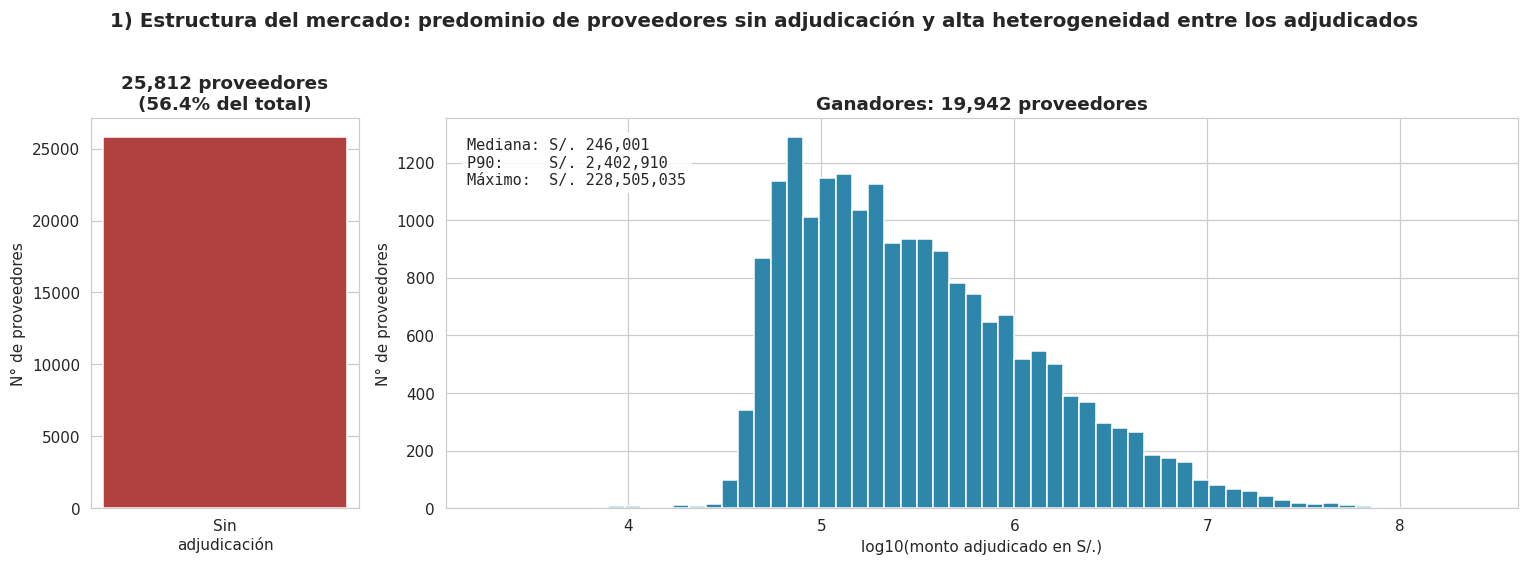

In [ ]:

# 1) MERCADO EN DOS PARTES: los que no ganan vs los que sí

sin_adj = (df_proveedores['monto_total_adjudicado'] == 0).sum()
con_adj = df_proveedores.loc[df_proveedores['monto_total_adjudicado'] > 0, 'monto_total_adjudicado']

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'width_ratios': [1, 4]})

axes[0].bar(['Sin\nadjudicación'], [sin_adj], color='#B0413E', edgecolor='white')
axes[0].set_ylabel('N° de proveedores')
axes[0].set_title(f'{sin_adj:,} proveedores\n({sin_adj/len(df_proveedores)*100:.1f}% del total)')
axes[0].grid(axis='x')

axes[1].hist(np.log10(con_adj), bins=60, color='#2E86AB', edgecolor='white')
axes[1].set_title(f'Ganadores: {len(con_adj):,} proveedores')
axes[1].set_xlabel('log10(monto adjudicado en S/.)')
axes[1].set_ylabel('N° de proveedores')
axes[1].text(0.02, 0.95,
             f"Mediana: S/. {con_adj.median():,.0f}\n"
             f"P90:     S/. {con_adj.quantile(0.9):,.0f}\n"
             f"Máximo:  S/. {con_adj.max():,.0f}",
             transform=axes[1].transAxes, va='top', family='monospace',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

fig.suptitle('1) Estructura del mercado: predominio de proveedores sin adjudicación y alta heterogeneidad entre los adjudicados',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

#1) Estructura del mercado: ~mitad no gana nada, la otra mitad es long-tail

### Hallazgos — Estructura del mercado según monto adjudicado

El gráfico evidencia una marcada heterogeneidad entre los proveedores que participan en las contrataciones de municipalidades provinciales.

- De los **45,754 proveedores analizados**, **25,812 (56.4%) no registraron ningún monto adjudicado** durante el periodo estudiado. Esto indica que más de la mitad de los proveedores participa en los procesos de contratación sin obtener adjudicaciones dentro del universo analizado.

- Los **19,942 proveedores restantes (43.6%)** sí obtuvieron al menos una adjudicación. Sin embargo, los montos obtenidos presentan una distribución fuertemente asimétrica, con una **cola larga hacia los valores elevados**.

- Entre los proveedores adjudicados, la **mediana del monto acumulado es aproximadamente S/ 246 mil**, lo que significa que la mitad de los ganadores obtuvo montos inferiores a este valor.

- El **percentil 90 es aproximadamente S/ 2.40 millones**, evidenciando que solamente una fracción reducida de proveedores alcanza montos adjudicados de varios millones de soles.

- El valor máximo supera los **S/ 228.5 millones**, muy por encima de la mediana y del percentil 90, lo que confirma la existencia de proveedores con escalas económicas considerablemente mayores que el resto.

### Interpretación respecto al problema

Estos resultados muestran que el mercado no está compuesto por proveedores con niveles similares de éxito económico. Existe una primera diferenciación entre proveedores que participan pero no obtienen adjudicaciones y proveedores que sí resultan adjudicados. Dentro de estos últimos también existe una elevada heterogeneidad en los montos obtenidos.

Por tanto, el monto adjudicado constituye una dimensión relevante para la identificación posterior de segmentos naturales de proveedores, pudiendo contribuir a diferenciar perfiles de baja, media y alta escala económica.



---


*El gráfico todavía no identifica los segmentos, pero demuestra que existe heterogeneidad suficiente como para justificar su búsqueda mediante técnicas de clustering.*


---



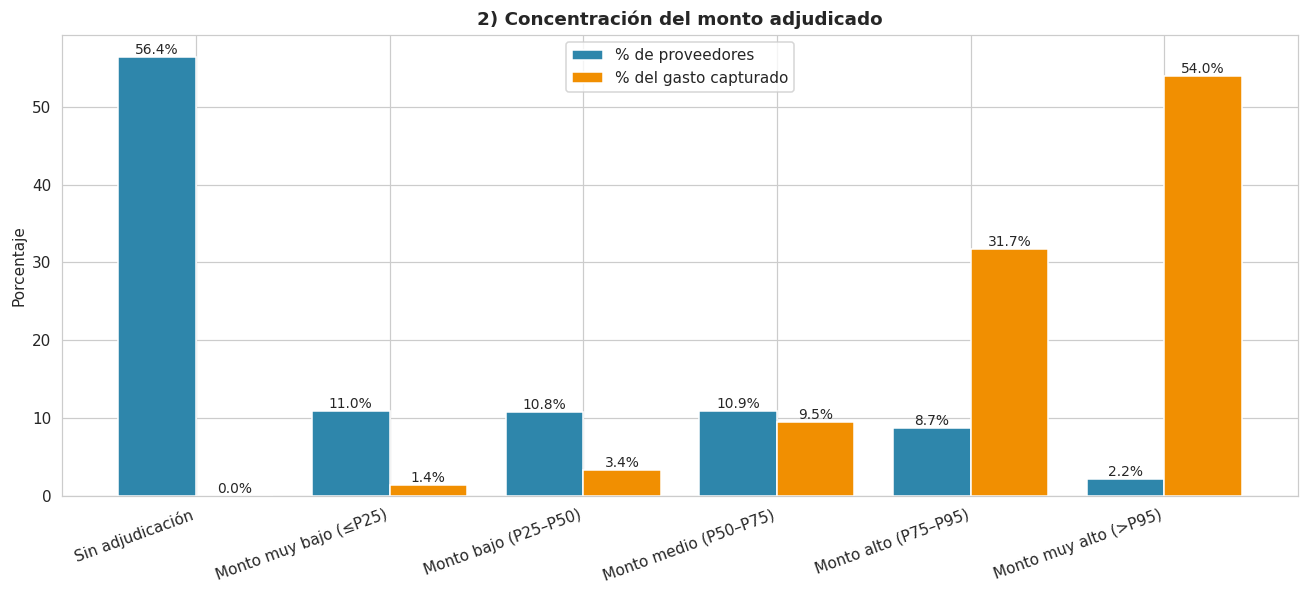

→ El segmento TOP: 2.2% de proveedores captura 54.0% del gasto


In [ ]:
# 2) CATEGORÍAS DE TAMAÑO — concentración del gasto (Pareto)

resumen = df_proveedores.groupby('tamano_proveedor').agg(
    n_prov=('ruc_proveedor', 'count'),
    monto_total=('monto_total_adjudicado', 'sum'),
    tasa_adj=('tasa_adjudicacion', 'mean'),
    pct_penalizados=('tiene_penalidades', lambda x: x.mean() * 100)
).reset_index()
resumen['pct_prov']  = resumen['n_prov']  / resumen['n_prov'].sum() * 100
resumen['pct_monto'] = resumen['monto_total'] / resumen['monto_total'].sum() * 100

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(resumen))
w = 0.4
b1 = ax.bar(x - w/2, resumen['pct_prov'],  w, label='% de proveedores',
            color='#2E86AB', edgecolor='white')
b2 = ax.bar(x + w/2, resumen['pct_monto'], w, label='% del gasto capturado',
            color='#F18F01', edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(resumen['tamano_proveedor'].astype(str), rotation=20, ha='right')
ax.set_ylabel('Porcentaje')
ax.set_title('2) Concentración del monto adjudicado')
ax.legend()
plt.tight_layout(); plt.show()

top = resumen.iloc[-1]
print(f"→ El segmento TOP: {top['pct_prov']:.1f}% de proveedores captura "
      f"{top['pct_monto']:.1f}% del gasto")

#2) Concentración del gasto público: ¿pocos proveedores capturan casi todo? (Pareto)

### Hallazgos — Concentración del monto adjudicado

El gráfico evidencia una alta concentración del monto adjudicado en una proporción reducida de proveedores.

- El **56.4% de los proveedores no registra adjudicaciones**, por lo que no concentra monto adjudicado durante el periodo analizado.

- Los proveedores de **monto muy bajo y monto bajo** representan conjuntamente el **21.8% del total de proveedores**, pero concentran solamente el **4.8% del monto adjudicado**.

- Los proveedores de **monto medio** representan el **10.9% de los proveedores** y concentran el **9.5% del monto adjudicado**.

- Los proveedores de **monto alto (P75–P95)** representan solo el **8.7% del total**, pero concentran el **31.7% del monto adjudicado**.

- El grupo de **monto muy alto (>P95)** representa apenas el **2.2% de todos los proveedores**, pero concentra el **54.0% del monto total adjudicado**.

- En conjunto, los proveedores de **monto alto y muy alto** representan solamente el **10.9% del total de proveedores**, pero concentran aproximadamente el **85.7% de todo el monto adjudicado**.

### Interpretación respecto al problema

Los resultados muestran una marcada heterogeneidad en la escala económica de los proveedores. Aunque existe una gran cantidad de participantes, la mayor parte del monto adjudicado se concentra en una fracción relativamente pequeña de ellos.

Esta concentración sugiere la coexistencia de proveedores con perfiles económicos diferentes: desde participantes sin adjudicación o con montos reducidos hasta un grupo minoritario que obtiene una proporción considerable del monto total adjudicado.

Por tanto, el monto total adjudicado constituye una variable relevante para la posterior identificación de segmentos naturales de proveedores.


---


 **Nota important:** Los percentiles P25, P50, P75 y P95 se calculan únicamente entre los proveedores que registran adjudicaciones. En cambio, los porcentajes de proveedores mostrados en el gráfico se calculan respecto al total de proveedores analizados.

Departamentos detectados en df_proveedores: 24
Descargando geojson departamental...
Departamentos del mapa con datos: 24 / 24


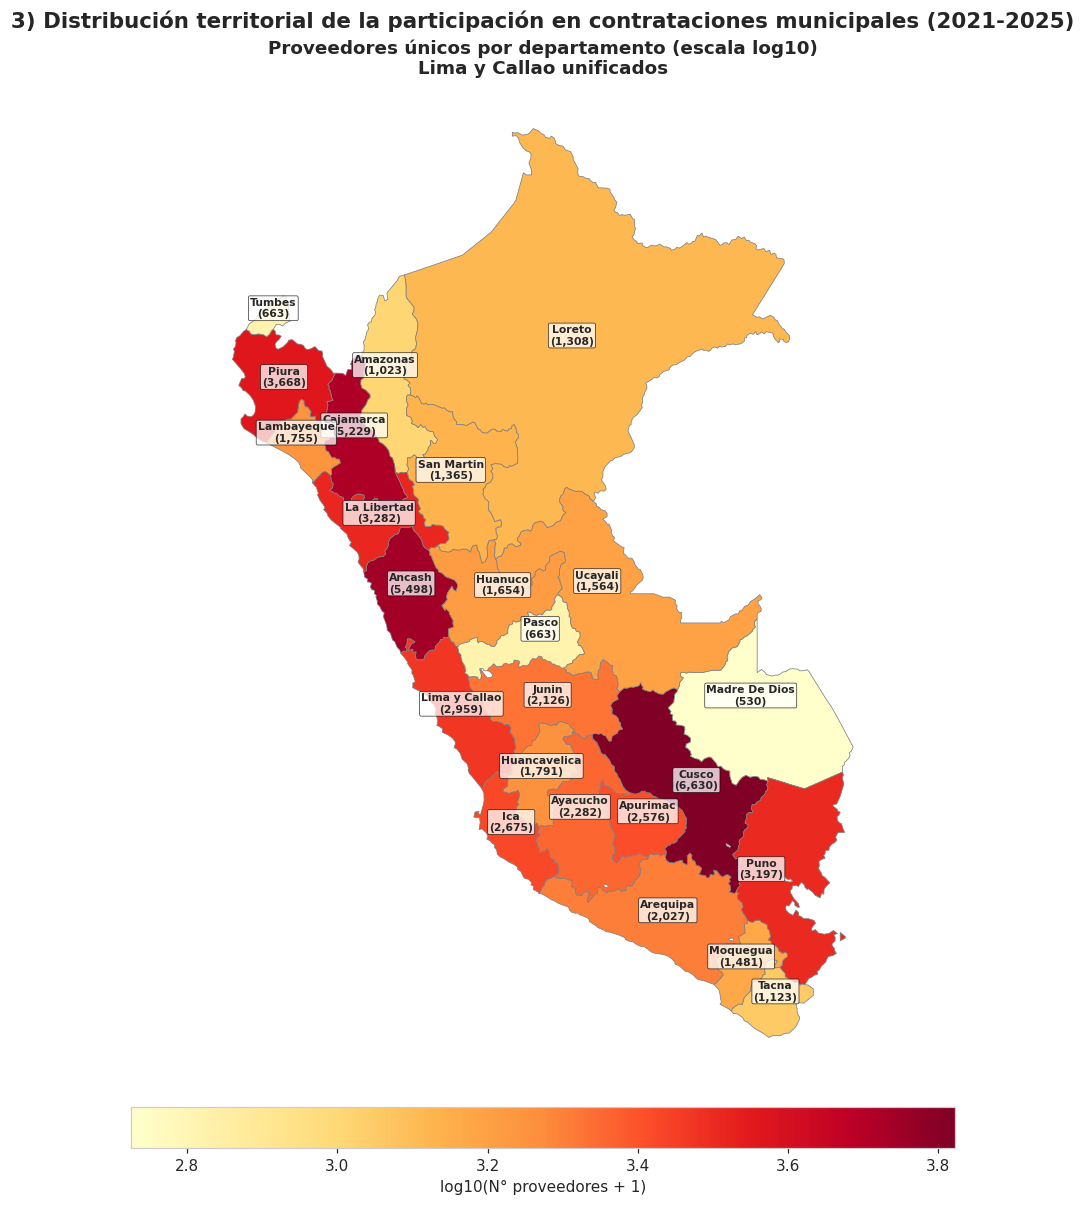


Resumen territorial:
   • Departamentos con al menos 1 proveedor: 24
   • Top 5 departamentos concentran el 42.6% del total de participaciones

Ranking completo de departamentos:
 departamento  n_proveedores
        CUSCO           6630
       ANCASH           5498
    CAJAMARCA           5229
        PIURA           3668
  LA LIBERTAD           3282
         PUNO           3197
LIMA Y CALLAO           2959
          ICA           2675
     APURIMAC           2576
     AYACUCHO           2282
        JUNIN           2126
     AREQUIPA           2027
 HUANCAVELICA           1791
   LAMBAYEQUE           1755
      HUANUCO           1654
      UCAYALI           1564
     MOQUEGUA           1481
   SAN MARTIN           1365
       LORETO           1308
        TACNA           1123
     AMAZONAS           1023
        PASCO            663
       TUMBES            663
MADRE DE DIOS            530


In [ ]:
# ============================================================
# 3) DISTRIBUCIÓN TERRITORIAL DE LA PARTICIPACIÓN (DEPARTAMENTAL)
#    Pregunta: ¿En qué departamentos se concentra la participación
#              de proveedores en municipalidades provinciales?
# ============================================================
import os, requests, unicodedata, re
try:
    import geopandas as gpd
except ImportError:
    os.system('pip install -q geopandas')
    import geopandas as gpd

def norm(t):
    if pd.isna(t): return ''
    t = str(t).strip().upper()
    t = unicodedata.normalize('NFKD', t).encode('ascii', 'ignore').decode('ascii')
    return re.sub(r'\s+', ' ', t)

# ---- 1) explotar departamentos_participacion → 1 fila por (proveedor, departamento)
tmp = (df_proveedores[['ruc_proveedor', 'departamentos_participacion']]
       .dropna(subset=['departamentos_participacion'])
       .assign(departamento=lambda x: x['departamentos_participacion'].str.split(','))
       .explode('departamento'))
tmp['departamento'] = tmp['departamento'].str.strip()
tmp = tmp[tmp['departamento'] != '']

# >>> Unificar LIMA + CALLAO en una sola categoría "LIMA Y CALLAO"
tmp['departamento'] = tmp['departamento'].apply(
    lambda x: 'LIMA Y CALLAO' if norm(x) in ('LIMA', 'CALLAO') else x
)

conteo_dep = (tmp.drop_duplicates()
                 .groupby('departamento')['ruc_proveedor']
                 .nunique()
                 .reset_index()
                 .rename(columns={'ruc_proveedor': 'n_proveedores'}))
conteo_dep['dep_key'] = conteo_dep['departamento'].map(norm)
print(f"Departamentos detectados en df_proveedores: {len(conteo_dep)}")

# ---- 2) descargar geojson departamental (25 departamentos)
GEOJSON_URL = "https://raw.githubusercontent.com/juaneladio/peru-geojson/master/peru_departamental_simple.geojson"
GEO_LOCAL   = "/tmp/peru_departamentos.geojson"
if not os.path.exists(GEO_LOCAL):
    print("Descargando geojson departamental...")
    r = requests.get(GEOJSON_URL, timeout=60)
    with open(GEO_LOCAL, 'wb') as f: f.write(r.content)
gdf = gpd.read_file(GEO_LOCAL)

col_geo_dep = next((c for c in ['NOMBDEP', 'DEPARTAMEN', 'DEPARTAMENTO', 'nombre', 'name']
                    if c in gdf.columns), None)
gdf['dep_key_orig'] = gdf[col_geo_dep].map(norm)

# >>> Unificar geometrías de LIMA y CALLAO en una sola figura "LIMA Y CALLAO"
gdf['dep_key'] = gdf['dep_key_orig'].replace({'LIMA': 'LIMA Y CALLAO',
                                              'CALLAO': 'LIMA Y CALLAO'})
gdf['nombre_dep'] = gdf.apply(
    lambda r: 'Lima y Callao' if r['dep_key'] == 'LIMA Y CALLAO'
    else str(r[col_geo_dep]).title(), axis=1
)
gdf = gdf.dissolve(by='dep_key', as_index=False, aggfunc={'nombre_dep': 'first'})

# ---- 3) join
gdfm = gdf.merge(conteo_dep[['dep_key', 'n_proveedores']], on='dep_key', how='left')
gdfm['n_proveedores'] = gdfm['n_proveedores'].fillna(0)
gdfm['n_prov_log']    = np.log10(gdfm['n_proveedores'] + 1)

n_match = (gdfm['n_proveedores'] > 0).sum()
print(f"Departamentos del mapa con datos: {n_match} / {len(gdfm)}")
no_match = set(conteo_dep['dep_key']) - set(gdf['dep_key'])
if no_match:
    print(f"⚠ {len(no_match)} nombres del df_proveedores no calzaron con el geojson:")
    print(" ", sorted(list(no_match)))

# ---- 4) plot: solo mapa
fig, ax = plt.subplots(1, 1, figsize=(11, 12))

gdfm.plot(column='n_prov_log',
          cmap='YlOrRd',
          linewidth=0.5,
          edgecolor='grey',
          legend=True,
          legend_kwds={'label': 'log10(N° proveedores + 1)',
                       'orientation': 'horizontal', 'shrink': 0.7, 'pad': 0.02},
          ax=ax,
          missing_kwds={'color': '#eeeeee', 'edgecolor': 'grey'})

# etiquetar TODOS los departamentos (ahora 24: se fusionó Lima+Callao)
for _, row in gdfm.iterrows():
    if row['n_proveedores'] > 0:
        c = row.geometry.representative_point()
        ax.annotate(f"{row['nombre_dep']}\n({int(row['n_proveedores']):,})",
                    xy=(c.x, c.y), ha='center', fontsize=7, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              ec='black', alpha=0.75, lw=0.5))

ax.set_title('Proveedores únicos por departamento (escala log10)\nLima y Callao unificados',
             fontsize=12, fontweight='bold')
ax.set_axis_off()

fig.suptitle('3) Distribución territorial de la participación en contrataciones municipales (2021-2025)',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(); plt.show()

# ---- 5) resumen textual
total_dep_con_datos = (conteo_dep['n_proveedores'] > 0).sum()
top5_share = (conteo_dep.nlargest(5, 'n_proveedores')['n_proveedores'].sum() /
              conteo_dep['n_proveedores'].sum() * 100)

print(f"\nResumen territorial:")
print(f"   • Departamentos con al menos 1 proveedor: {total_dep_con_datos}")
print(f"   • Top 5 departamentos concentran el {top5_share:.1f}% del total de participaciones")
print(f"\nRanking completo de departamentos:")
print(conteo_dep.sort_values('n_proveedores', ascending=False)
      [['departamento', 'n_proveedores']].to_string(index=False))

### Hallazgos — Distribución territorial de la participación

El mapa evidencia una distribución territorial **heterogénea y descentralizada** de los proveedores que participan en contrataciones de municipalidades provinciales durante 2021–2025.

- **Cusco** concentra la mayor cantidad de proveedores únicos con **6,630**, seguido de **Ancash (5,498)** y **Cajamarca (5,229)**, consolidándose como los tres departamentos con mayor participación del país.

- Un segundo bloque, con presencia intermedia-alta, está formado por **Piura (3,668)**, **La Libertad (3,282)** y **Puno (3,197)**, que refuerzan el eje costa-norte y sur andino como zonas de alta actividad contractual.

- Los departamentos con participación intermedia incluyen **Lima y Callao (2,959)**, **Ica (2,675)**, **Apurímac (2,576)**, **Ayacucho (2,282)**, **Junín (2,126)** y **Arequipa (2,027)**, reflejando una distribución relativamente amplia por la sierra centro-sur y la costa central.

- Los departamentos con menor número de proveedores son **Madre de Dios (530)**, **Pasco (663)**, **Tumbes (663)** y **Amazonas (1,023)**, que corresponden a jurisdicciones más pequeñas, con menor densidad económica o menor volumen de convocatorias municipales.

Se observa además que **Lima y Callao no dominan la participación**, con solo 2,959 proveedores únicos — muy por debajo de Cusco, Ancash y Cajamarca. Esto contrasta con la concentración económica típica del país y sugiere que las contrataciones de **municipalidades provinciales** funcionan como un mercado descentralizado, más ligado a la geografía de los gobiernos locales que a la concentración empresarial nacional.

## Interpretación respecto al problema

Los resultados muestran que el alcance territorial no está concentrado en un solo eje geográfico, sino distribuido a lo largo de la sierra norte, sierra sur y costa norte, con Cusco, Ancash y Cajamarca como núcleos principales de participación de proveedores.

Esta distribución sugiere la existencia de **mercados regionales relativamente independientes**, donde cada departamento configura su propio ecosistema de proveedores en función de la actividad municipal local, la densidad de gobiernos provinciales y la dinámica económica regional.

La marcada diferencia entre departamentos con más de 5,000 proveedores (Cusco, Ancash, Cajamarca) y aquellos con menos de 700 (Madre de Dios, Pasco, Tumbes) evidencia una **heterogeneidad territorial estructural** que debe ser incorporada en el análisis, ya que el comportamiento y las oportunidades de un proveedor dependen fuertemente del contexto departamental en el que opera.

Por tanto, el alcance territorial constituye una variable relevante para la posterior identificación de segmentos naturales de proveedores, en tanto permite distinguir perfiles con presencia local acotada frente a perfiles con capacidad de operar en múltiples jurisdicciones.

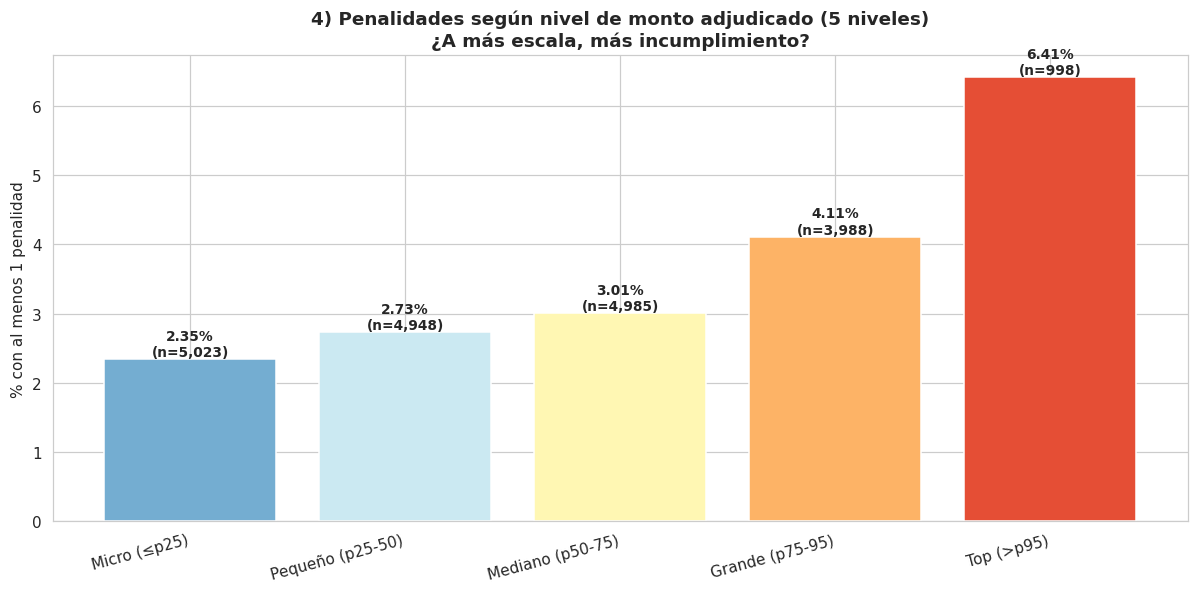


Detalle por nivel:
tamano_proveedor  n_prov  pct_pen
    Micro (≤p25)    5023     2.35
Pequeño (p25-50)    4948     2.73
Mediano (p50-75)    4985     3.01
 Grande (p75-95)    3988     4.11
      Top (>p95)     998     6.41

→ Los proveedores TOP tienen 2.7× más probabilidad de tener penalidades que los MICRO (6.41% vs 2.35%)


In [ ]:
# ============================================================
# 4) PENALIDADES SEGÚN NIVEL DE MONTO ADJUDICADO (5 NIVELES)
#    Versión autocontenida — no depende de celdas previas
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- filtrar solo proveedores con adjudicación ---
adj = df_proveedores[df_proveedores['monto_total_adjudicado'] > 0].copy()

# --- crear categorías de tamaño (por si no existen) ---
q = adj['monto_total_adjudicado'].quantile([0.25, 0.50, 0.75, 0.95]).values
labels_tam = ['Micro (≤p25)', 'Pequeño (p25-50)', 'Mediano (p50-75)',
              'Grande (p75-95)', 'Top (>p95)']
bins = [-np.inf, q[0], q[1], q[2], q[3], np.inf]
adj['tamano_proveedor'] = pd.cut(adj['monto_total_adjudicado'],
                                 bins=bins, labels=labels_tam)
adj['tamano_proveedor'] = pd.Categorical(adj['tamano_proveedor'],
                                         categories=labels_tam, ordered=True)

# --- resumen: % de proveedores con al menos 1 penalidad por nivel ---
resumen_pen5 = adj.groupby('tamano_proveedor', observed=True).agg(
    n_prov=('ruc_proveedor', 'count'),
    pct_pen=('tiene_penalidades', lambda x: x.mean() * 100)
).reset_index()

# --- gráfico ---
fig, ax = plt.subplots(figsize=(11, 5.5))
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.85, len(resumen_pen5)))
bars = ax.bar(resumen_pen5['tamano_proveedor'].astype(str),
              resumen_pen5['pct_pen'], color=colors, edgecolor='white')

for bar, n in zip(bars, resumen_pen5['n_prov']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.2f}%\n(n={n:,})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('% con al menos 1 penalidad')
ax.set_title('4) Penalidades según nivel de monto adjudicado (5 niveles)\n'
             '¿A más escala, más incumplimiento?')
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()

# --- resumen textual ---
print("\nDetalle por nivel:")
print(resumen_pen5.round(2).to_string(index=False))

ratio = resumen_pen5['pct_pen'].iloc[-1] / resumen_pen5['pct_pen'].iloc[0]
print(f"\n→ Los proveedores TOP tienen {ratio:.1f}× más probabilidad de "
      f"tener penalidades que los MICRO "
      f"({resumen_pen5['pct_pen'].iloc[-1]:.2f}% vs {resumen_pen5['pct_pen'].iloc[0]:.2f}%)")

### Hallazgos — Penalidades según nivel de monto adjudicado (5 niveles)


El gráfico segmenta a los proveedores con adjudicación en cinco niveles según el monto total obtenido, y presenta para cada nivel el porcentaje de proveedores con al menos una penalidad registrada. Los porcentajes están calculados sobre el total de cada nivel, no sobre el padrón completo.

- El nivel **Micro (≤ P25)**, con 5,023 proveedores, presenta una tasa de penalización del **2.35%**, la más baja de todos los grupos.

- El nivel **Pequeño (P25–P50)**, con 4,948 proveedores, incrementa la tasa a **2.73%**.

- El nivel **Mediano (P50–P75)**, con 4,985 proveedores, alcanza una tasa del **3.01%**.

- El nivel **Grande (P75–P95)**, con 3,988 proveedores, muestra un salto significativo hasta **4.11%**.

- El nivel **Top (>P95)**, con solo 998 proveedores, presenta la tasa más alta del padrón con un **6.41%** de proveedores penalizados.

Comparando los extremos, los proveedores del segmento Top presentan **2.7 veces más probabilidad** de tener penalidades que los del segmento Micro (6.41% vs 2.35%). Además, la relación entre escala económica y tasa de penalización es **monotónica creciente**: cada nivel superior de monto adjudicado registra una tasa de penalización mayor que el anterior, sin excepciones.

## Interpretación respecto al problema

Los resultados evidencian una **relación estructural entre la escala económica del proveedor y su probabilidad de haber sido penalizado**. A medida que aumenta el monto adjudicado, aumenta también la proporción de proveedores con al menos un incumplimiento registrado, siguiendo un patrón escalonado y consistente.

Este hallazgo sugiere que la exposición contractual es un **factor de riesgo determinante**: los proveedores que ganan más contratos tienen naturalmente más oportunidades de incumplir, pero además el crecimiento no es lineal, sino que se acentúa en los tramos superiores. El salto entre el segmento Grande (4.11%) y el segmento Top (6.41%) muestra que los proveedores de mayor escala no solo enfrentan más contratos, sino también mayores riesgos operacionales o exigencias contractuales.

Sin embargo, es importante señalar que las tasas se mantienen relativamente bajas en términos absolutos (menos del 7% incluso en el segmento más alto), lo que indica que la penalidad continúa siendo un evento infrecuente. Lo relevante no es su volumen absoluto, sino su **distribución sesgada hacia los proveedores de mayor escala**.

Por tanto, la combinación entre monto adjudicado y presencia de penalidades constituye una variable relevante para la posterior identificación de segmentos naturales de proveedores, en tanto permite distinguir perfiles con exposición contractual limitada frente a perfiles con alta actividad económica y mayor riesgo asociado.

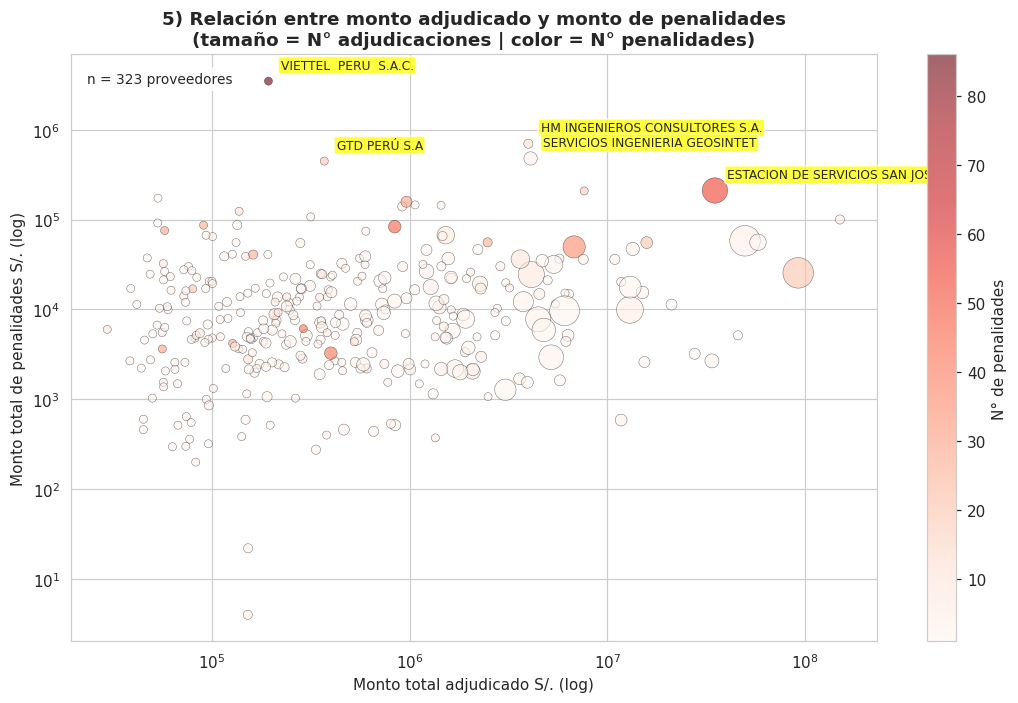


323 proveedores tienen monto adjudicado y monto de penalidades mayores a cero.

Top 5 por monto acumulado de penalidades:
ruc_proveedor                            nombre_proveedor  monto_total_adjudicado  n_items_adjudicados  n_penalidades  monto_penalidades
  20543254798                       VIETTEL  PERU  S.A.C.               193024.00                    1             86          3466655.0
  20543698912              HM INGENIEROS CONSULTORES S.A.              3983000.00                    2             12           698186.0
  20601869846 SERVICIOS INGENIERIA GEOSINTETICOS E.I.R.L.              4089017.68                    7              2           478495.0
  20421780472                                GTD PERÚ S.A               369986.64                    1             19           447659.0
  20175642341       ESTACION DE SERVICIOS SAN JOSE S.A.C.             34989911.80                   32             54           210557.0


In [ ]:
# 5) SCATTER LOG-LOG: monto adjudicado vs monto de penalidades
# Solo proveedores con ambos montos positivos

d = df_proveedores[
    (df_proveedores['monto_total_adjudicado'] > 0) &
    (df_proveedores['monto_penalidades'] > 0)
].copy()

fig, ax = plt.subplots(figsize=(10, 6.5))

sc = ax.scatter(
    d['monto_total_adjudicado'],
    d['monto_penalidades'],
    c=d['n_penalidades'],
    cmap='Reds',
    s=np.clip(d['n_items_adjudicados'] * 8 + 20, 20, 400),
    alpha=0.6,
    edgecolor='black',
    linewidth=0.3
)

# Escalas logarítmicas
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Monto total adjudicado S/. (log)')
ax.set_ylabel('Monto total de penalidades S/. (log)')

ax.set_title(
    '5) Relación entre monto adjudicado y monto de penalidades\n'
    '(tamaño = N° adjudicaciones | color = N° penalidades)'
)

plt.colorbar(
    sc,
    ax=ax,
    label='N° de penalidades'
)

# Etiquetar los 5 proveedores con mayor monto de penalidades
top5_pen = d.nlargest(5, 'monto_penalidades')

for _, row in top5_pen.iterrows():

    nombre = str(
        row.get(
            'nombre_proveedor',
            row['ruc_proveedor']
        )
    )[:30]

    ax.annotate(
        nombre,
        xy=(
            row['monto_total_adjudicado'],
            row['monto_penalidades']
        ),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=8,
        bbox=dict(
            boxstyle='round,pad=0.2',
            fc='yellow',
            alpha=0.75
        )
    )

# Número de proveedores efectivamente representados
ax.text(
    0.02,
    0.97,
    f'n = {len(d):,} proveedores',
    transform=ax.transAxes,
    va='top',
    fontsize=9,
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.85
    )
)

plt.tight_layout()
plt.show()

# Resultados complementarios
print(
    f"\n{len(d):,} proveedores tienen monto adjudicado "
    f"y monto de penalidades mayores a cero."
)

print("\nTop 5 por monto acumulado de penalidades:")

print(
    top5_pen[
        [
            'ruc_proveedor',
            'nombre_proveedor',
            'monto_total_adjudicado',
            'n_items_adjudicados',
            'n_penalidades',
            'monto_penalidades'
        ]
    ].to_string(index=False)
)

### Hallazgos — Relación entre monto adjudicado y monto de penalidades

El gráfico analiza a los **323 proveedores que presentan simultáneamente un monto adjudicado mayor a cero y un monto monetario de penalidades mayor a cero**.

- Se observa una **amplia dispersión** tanto en los montos adjudicados como en los montos acumulados de penalidades. Por esta razón, ambas variables se representan en escala logarítmica.

- Visualmente, **no se aprecia una relación proporcional clara** entre el monto adjudicado y el monto de penalidades. Es decir, obtener un mayor monto adjudicado no implica necesariamente registrar un mayor monto de penalidades.

- Existen proveedores con **montos adjudicados elevados pero penalidades relativamente moderadas**, mientras que otros proveedores con montos adjudicados considerablemente menores presentan montos de penalidad elevados.

- El número de penalidades también presenta una elevada heterogeneidad. El color de los puntos muestra que algunos proveedores acumulan numerosas penalidades, mientras que otros presentan pocas penalidades pero de elevado valor monetario.

- El tamaño de los puntos evidencia además diferencias en el número de ítems adjudicados, mostrando que proveedores con escalas económicas similares pueden presentar frecuencias de adjudicación muy diferentes.

- Entre los casos con mayor monto acumulado de penalidades destacan proveedores como **VIETTEL PERU S.A.C.**, **HM INGENIEROS CONSULTORES S.A.**, **SERVICIOS INGENIERIA GEOSINTETICOS E.I.R.L.**, **GTD PERÚ S.A.** y **ESTACION DE SERVICIOS SAN JOSE S.A.C.**. Estos casos constituyen valores extremos que requieren una revisión individual antes de obtener conclusiones sustantivas.

### Interpretación respecto al problema

Los resultados evidencian que, incluso dentro del grupo de proveedores que presentan penalidades monetarias, existen comportamientos heterogéneos en términos de **escala económica, número de adjudicaciones, frecuencia de penalización y monto acumulado de penalidades**.

Esta dispersión refuerza la idea de que los proveedores que participan en contrataciones de municipalidades provinciales no constituyen un grupo homogéneo y que sus características deben analizarse de manera conjunta para identificar posteriormente perfiles diferenciados.

Las penalidades pueden resultar especialmente útiles como variables de **caracterización posterior de los clusters**, permitiendo evaluar si determinados segmentos presentan una mayor frecuencia o magnitud de penalizaciones.


---


 **Nota metodológica:** No debe interpretarse este gráfico como evidencia de que un mayor monto adjudicado causa mayores penalidades. Asimismo, algunos casos presentan montos acumulados de penalidad superiores al monto adjudicado observado dentro del universo analizado. Esto sugiere que la fuente de penalidades puede contener registros que no estén vinculados exactamente a las mismas contrataciones de municipalidades provinciales utilizadas para calcular el monto adjudicado, por lo que los casos extremos deben validarse antes de realizar interpretaciones individuales.

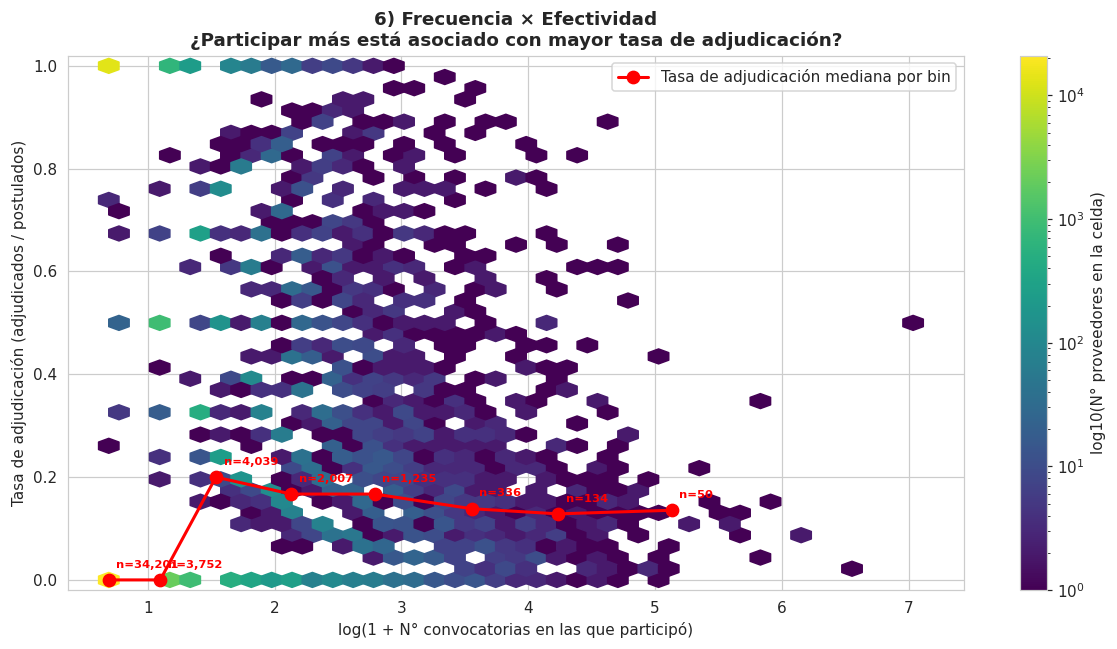


Mediana de tasa de adjudicación por bin de frecuencia:
bin_convocatorias  tasa_mediana     n
                1        0.0000 34201
                2        0.0000  3752
              3-5        0.2000  4039
             6-10        0.1670  2007
            11-25        0.1670  1235
            26-50        0.1385   336
           51-100        0.1285   134
             100+        0.1355    50


In [ ]:
# ============================================================
# 6) FRECUENCIA × TASA DE ADJUDICACIÓN (efectividad)
#    Pregunta: ¿participar más está asociado con mayor efectividad?
#    (hexbin + medianas por bin de frecuencia)
# ============================================================
d6 = df_proveedores[df_proveedores['n_convocatorias'] > 0].copy()
d6['log_conv'] = np.log1p(d6['n_convocatorias'])

fig, ax = plt.subplots(figsize=(11, 6))
hb = ax.hexbin(d6['log_conv'], d6['tasa_adjudicacion'],
               gridsize=40, cmap='viridis', mincnt=1, bins='log')
cb = plt.colorbar(hb, ax=ax); cb.set_label('log10(N° proveedores en la celda)')

# mediana de tasa por bin de frecuencia
bins_conv = pd.cut(d6['n_convocatorias'],
                   bins=[0, 1, 2, 5, 10, 25, 50, 100, np.inf],
                   labels=['1', '2', '3-5', '6-10', '11-25', '26-50', '51-100', '100+'])
med = d6.groupby(bins_conv, observed=True).agg(
    tasa_mediana=('tasa_adjudicacion', 'median'),
    log_conv_medio=('log_conv', 'mean'),
    n=('ruc_proveedor', 'count')
).reset_index()

ax.plot(med['log_conv_medio'], med['tasa_mediana'],
        'o-', color='red', lw=2, markersize=8,
        label='Tasa de adjudicación mediana por bin', zorder=5)

for _, row in med.iterrows():
    ax.annotate(f"n={int(row['n']):,}",
                xy=(row['log_conv_medio'], row['tasa_mediana']),
                xytext=(5, 8), textcoords='offset points',
                fontsize=7.5, color='red', fontweight='bold')

ax.set_xlabel('log(1 + N° convocatorias en las que participó)')
ax.set_ylabel('Tasa de adjudicación (adjudicados / postulados)')
ax.set_title('6) Frecuencia × Efectividad\n'
             '¿Participar más está asociado con mayor tasa de adjudicación?')
ax.legend(loc='upper right')
ax.set_ylim(-0.02, 1.02)
plt.tight_layout(); plt.show()

print("\nMediana de tasa de adjudicación por bin de frecuencia:")
print(med[['n_convocatorias', 'tasa_mediana', 'n']].rename(
    columns={'n_convocatorias': 'bin_convocatorias'}).to_string(index=False))

### Hallazgos — Frecuencia × Efectividad

El gráfico relaciona la frecuencia de participación (número de convocatorias en escala logarítmica) con la tasa de adjudicación (adjudicados / postulados) para todos los proveedores del padrón. La línea roja representa la tasa mediana de adjudicación calculada por bin de frecuencia, junto con el número de proveedores en cada bin.

- El bin de **1 convocatoria** concentra la mayor masa del padrón, con **34,201 proveedores**, y presenta una tasa mediana de adjudicación de **0%**. Es decir, tres de cada cuatro proveedores del padrón postulan una sola vez y no ganan.

- El bin de **2 convocatorias** agrupa **3,752 proveedores** y mantiene la tasa mediana en **0%**, confirmando que participar dos veces todavía no garantiza adjudicaciones.

- El bin de **3 a 5 convocatorias**, con **4,039 proveedores**, muestra un salto abrupto en la efectividad: la tasa mediana asciende a aproximadamente **20%**. Este punto marca un umbral claro de aprendizaje o consolidación.

- El bin de **6 a 10 convocatorias** (2,007 proveedores) presenta una tasa mediana cercana al **17%**, ligeramente inferior al bin anterior.

- Los bins de **11 a 25** (1,238 proveedores), **26 a 50** (356 proveedores), **51 a 100** (134 proveedores) y **más de 100** (56 proveedores) muestran tasas medianas estables entre **13% y 15%**, sin evidencia de mejora adicional pese al incremento sustancial en frecuencia.

En conjunto, los bins de 1 y 2 convocatorias suman **37,953 proveedores (83% del padrón)**, todos ellos con tasa mediana de adjudicación igual a cero. Esto significa que la enorme mayoría de proveedores registrados en el mercado municipal **participa de forma marginal y sin éxito**, mientras que la efectividad se concentra en el 17% restante que supera el umbral de 3 convocatorias.

Adicionalmente, la nube de puntos muestra que los proveedores con tasa de adjudicación cercana al **100%** se concentran casi exclusivamente en los bins de baja frecuencia (1–2 convocatorias). Estos corresponden a proveedores que postularon pocas veces y ganaron todas, lo que representa un caso particular de éxito puntual pero no sostenido.

## Interpretación respecto al problema

Los resultados evidencian que la relación entre frecuencia de participación y efectividad **no es lineal, sino escalonada**, con dos fenómenos claramente diferenciados:

Primero, existe un **umbral de aprendizaje o consolidación en las 3 convocatorias**. Los proveedores que participan una o dos veces prácticamente no ganan (tasa mediana de 0%), mientras que aquellos que superan las tres participaciones alcanzan tasas de adjudicación entre 13% y 20%. Esto sugiere que la efectividad en contrataciones municipales no se obtiene con una participación aislada, sino que requiere un mínimo de experiencia acumulada, familiaridad con los procesos y aprendizaje operativo.

Segundo, una vez superado ese umbral, **la efectividad se estabiliza y presenta rendimientos decrecientes**. Participar cinco veces o cien veces no cambia sustancialmente la probabilidad mediana de ganar un contrato, que se mantiene en torno al 13–15%. Esto indica que la frecuencia adicional deja de ser un factor diferenciador de éxito, y que otros elementos (especialización, capacidad económica, relación con entidades, calidad de propuesta) probablemente determinan las diferencias entre proveedores recurrentes.

En términos de segmentación, este gráfico revela **al menos tres perfiles naturales** en el mercado:

- **Perfil ocasional sin éxito**: proveedores con 1–2 convocatorias y tasa de adjudicación cercana a cero, que constituyen la enorme mayoría del padrón: aproximadamente **37,900 proveedores, equivalentes al 83% del total registrado**.
- **Perfil recurrente efectivo**: proveedores con 3 o más convocatorias y tasa estabilizada entre 13% y 20%, que representan el núcleo activo del mercado.
- **Perfil ocasional exitoso**: un grupo minoritario que gana la totalidad o la mayoría de sus escasas participaciones, posiblemente ligado a especializaciones o adjudicaciones directas.

Por tanto, la frecuencia de participación y la tasa de adjudicación son variables **complementarias y no redundantes** para la posterior identificación de segmentos naturales de proveedores. La frecuencia captura la intensidad de participación, mientras que la tasa refleja la eficiencia de esa participación, y su combinación permite diferenciar perfiles que no serían visibles analizando cada dimensión por separado.

Distribución por cuadrante (cortes: conv≥3, muni≥3):
  Ocasionales locales                :  37,953  ( 83.0%)
  Recurrentes diversificados         :   4,077  (  8.9%)
  Recurrentes concentrados           :   3,724  (  8.1%)


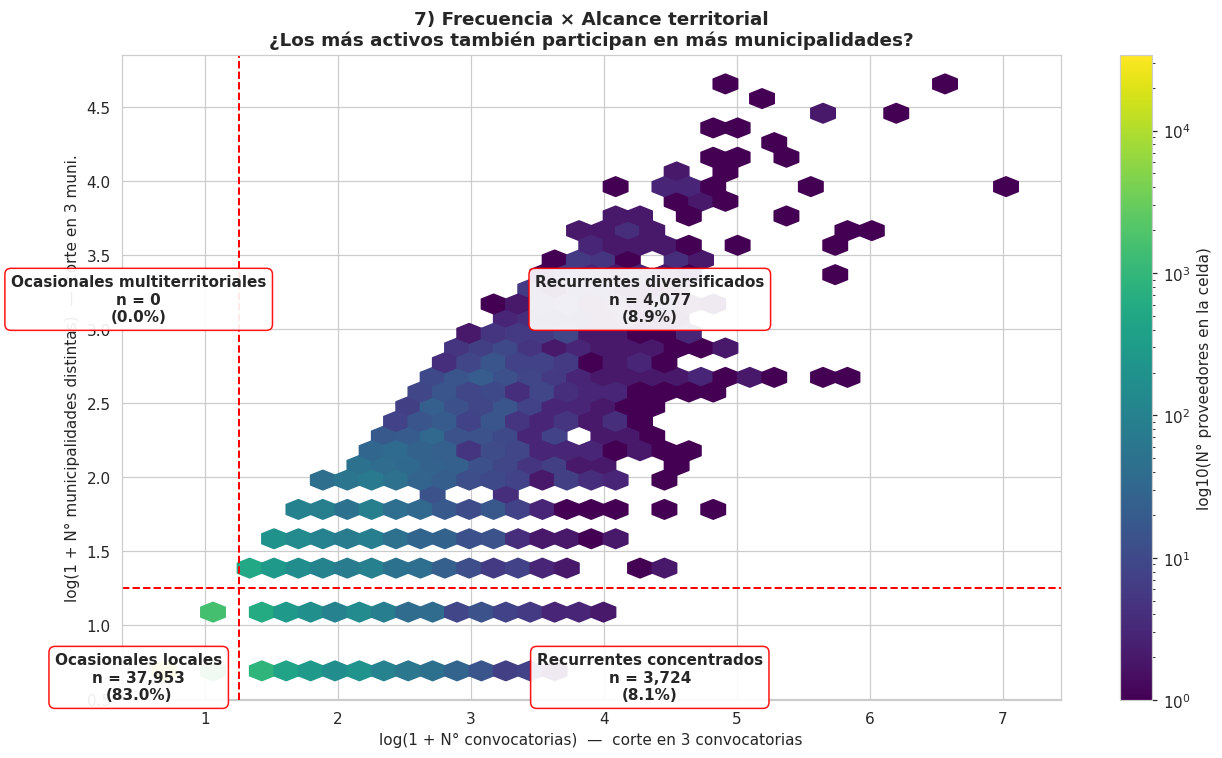

In [ ]:
# 7) FRECUENCIA × ALCANCE TERRITORIAL — versión corregida

df_proveedores['n_municipalidades_calc'] = (df_proveedores['municipalidades_participacion'].fillna('')
                                .apply(lambda s: len([x for x in s.split(',') if x.strip()])))

d7 = df_proveedores[df_proveedores['n_convocatorias'] > 0].copy()
d7['log_conv'] = np.log1p(d7['n_convocatorias'])
d7['log_muni'] = np.log1p(d7['n_municipalidades_calc'])

# ⚠ CORTES CONCEPTUALES (no la mediana, que está pegada al piso)
UMBRAL_CONV = 3    # a partir de 3 convocatorias = "recurrente" (vimos el umbral en el gráfico 6)
UMBRAL_MUNI = 3    # a partir de 3 municipalidades = "diversificado"

corte_x = np.log1p(UMBRAL_CONV - 0.5)  # línea entre bin 2 y bin 3
corte_y = np.log1p(UMBRAL_MUNI - 0.5)

# clasificar cada proveedor
d7['perfil_terr'] = np.select(
    [
        (d7['n_convocatorias'] <  UMBRAL_CONV) & (d7['n_municipalidades_calc'] <  UMBRAL_MUNI),
        (d7['n_convocatorias'] <  UMBRAL_CONV) & (d7['n_municipalidades_calc'] >= UMBRAL_MUNI),
        (d7['n_convocatorias'] >= UMBRAL_CONV) & (d7['n_municipalidades_calc'] <  UMBRAL_MUNI),
        (d7['n_convocatorias'] >= UMBRAL_CONV) & (d7['n_municipalidades_calc'] >= UMBRAL_MUNI),
    ],
    ['Ocasionales locales', 'Ocasionales multiterritoriales',
     'Recurrentes concentrados', 'Recurrentes diversificados'],
    default='?'
)

# contar
conteo_q = d7['perfil_terr'].value_counts()
total = len(d7)
print("Distribución por cuadrante (cortes: conv≥3, muni≥3):")
for k, v in conteo_q.items():
    print(f"  {k:35s}: {v:>7,}  ({v/total*100:5.1f}%)")

# gráfico
fig, ax = plt.subplots(figsize=(12, 7))
hb = ax.hexbin(d7['log_conv'], d7['log_muni'],
               gridsize=35, cmap='viridis', mincnt=1, bins='log')
plt.colorbar(hb, ax=ax, label='log10(N° proveedores en la celda)')

ax.axvline(corte_x, ls='--', color='red', lw=1.3)
ax.axhline(corte_y, ls='--', color='red', lw=1.3)

# posiciones de etiquetas: dentro de cada cuadrante REAL
xlim = ax.get_xlim(); ylim = ax.get_ylim()
posiciones = {
    'Ocasionales locales':            (corte_x*0.4,                corte_y*0.4),
    'Ocasionales multiterritoriales': (corte_x*0.4,                (ylim[1]+corte_y)/2),
    'Recurrentes concentrados':       ((xlim[1]+corte_x)/2,        corte_y*0.4),
    'Recurrentes diversificados':     ((xlim[1]+corte_x)/2,        (ylim[1]+corte_y)/2),
}

for label, (x, y) in posiciones.items():
    n = conteo_q.get(label, 0)
    pct = n / total * 100
    ax.text(x, y, f'{label}\nn = {n:,}\n({pct:.1f}%)',
            fontsize=10, ha='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='red', alpha=0.92))

ax.set_xlabel(f'log(1 + N° convocatorias)  —  corte en {UMBRAL_CONV} convocatorias')
ax.set_ylabel(f'log(1 + N° municipalidades distintas)  —  corte en {UMBRAL_MUNI} muni.')
ax.set_title('7) Frecuencia × Alcance territorial\n'
             '¿Los más activos también participan en más municipalidades?')
plt.tight_layout(); plt.show()

# Gráfico 7 — Frecuencia × Alcance territorial

## Resultados

El gráfico cruza dos dimensiones clave del comportamiento de los proveedores: la frecuencia de participación (número de convocatorias) y el alcance territorial (número de municipalidades distintas en las que participaron). Los cortes utilizados son de 3 convocatorias y 3 municipalidades, con el fin de separar la participación puntual de la recurrente y la operación local de la diversificada. El color indica la tasa de adjudicación de cada proveedor.

Los proveedores se distribuyen en cuatro cuadrantes conceptuales, aunque en la práctica solo tres están efectivamente poblados:

- **Ocasionales locales** (menos de 3 convocatorias y menos de 3 municipalidades): concentra el **83.0% del padrón**, con **37,953 proveedores**. Es la enorme mayoría del mercado y corresponde a proveedores con participación mínima y presencia geográfica reducida.

- **Recurrentes diversificados** (3 o más convocatorias en 3 o más municipalidades): representa el **8.9% del padrón**, con **4,077 proveedores**. Son proveedores que han acumulado participación en varias municipalidades y presentan una tasa de adjudicación efectiva.

- **Recurrentes concentrados** (3 o más convocatorias pero solo en 1 o 2 municipalidades): representa el **8.1% del padrón**, con **3,724 proveedores**. Son proveedores que participan repetidamente, pero siempre en las mismas pocas municipalidades.

- **Ocasionales multiterritoriales** (menos de 3 convocatorias pero en 3 o más municipalidades): este cuadrante está **prácticamente vacío**, con **0 proveedores (0.0%)**. La combinación de baja frecuencia y alta diversificación territorial es inexistente en el mercado observado.

Adicionalmente, la nube de datos muestra que la relación entre frecuencia y alcance es **fuertemente positiva y acumulativa**: a medida que un proveedor participa en más convocatorias, también incrementa el número de municipalidades en las que opera. Los proveedores con mayor frecuencia (log(1+n_convocatorias) > 4) se distribuyen exclusivamente en la zona superior del gráfico, con múltiples municipalidades cubiertas.

## Interpretación respecto al problema

Los resultados evidencian que la **frecuencia de participación y el alcance territorial son dimensiones fuertemente acopladas**: no existen proveedores que participen poco pero se distribuyan en muchos territorios. Esto tiene tres implicaciones importantes:

Primero, la **diversificación territorial requiere volumen previo de participación**. Un proveedor no puede operar en múltiples municipalidades sin haber acumulado experiencia y capacidad operativa suficiente. La expansión geográfica es, en la práctica, una consecuencia natural de la recurrencia en el mercado, no una estrategia independiente. Por eso el cuadrante de "Ocasionales multiterritoriales" resulta vacío: no es una omisión del análisis, sino un hallazgo que refleja la estructura real del mercado.

Segundo, el perfil de **"Recurrentes concentrados" (8.1%)** merece atención especial. Este grupo participa repetidamente, pero siempre en las mismas 1 o 2 municipalidades. Puede reflejar dos fenómenos distintos: (i) especialización legítima como proveedor de confianza en una jurisdicción específica, o (ii) concentración anómala que podría indicar relaciones privilegiadas con determinadas entidades. En cualquiera de los dos casos, este perfil es diferenciable y relevante para el análisis de segmentación y potencialmente para acciones de fiscalización.

Tercero, el perfil de **"Recurrentes diversificados" (8.9%)** representa el núcleo profesional del mercado. Son proveedores que han logrado escalar tanto en frecuencia como en cobertura geográfica, y probablemente coincidan con los proveedores de mayor escala económica identificados en gráficos previos (segmentos Grande y Top del gráfico 4), así como con los proveedores de trayectoria sostenida del gráfico 8.

En términos de segmentación, este gráfico revela **tres perfiles naturales claramente diferenciados** en el mercado:

- **Perfil ocasional local** (83.0%): la enorme mayoría, con participación mínima y sin alcance territorial.
- **Perfil recurrente concentrado** (8.1%): activos y experimentados, pero especializados en pocas municipalidades.
- **Perfil recurrente diversificado** (8.9%): activos, experimentados y con presencia en múltiples territorios.

La ausencia del cuarto perfil ("ocasionales multiterritoriales") no es un vacío del análisis, sino un hallazgo estructural del mercado: confirma que **la diversificación geográfica en contrataciones municipales no es viable sin recurrencia previa**.

Por tanto, la combinación entre frecuencia de participación y alcance territorial constituye una variable relevante para la posterior identificación de segmentos naturales de proveedores, en tanto permite diferenciar perfiles de operación puntual, concentrada y diversificada, cada uno con implicaciones distintas para el análisis del mercado de contrataciones municipales.

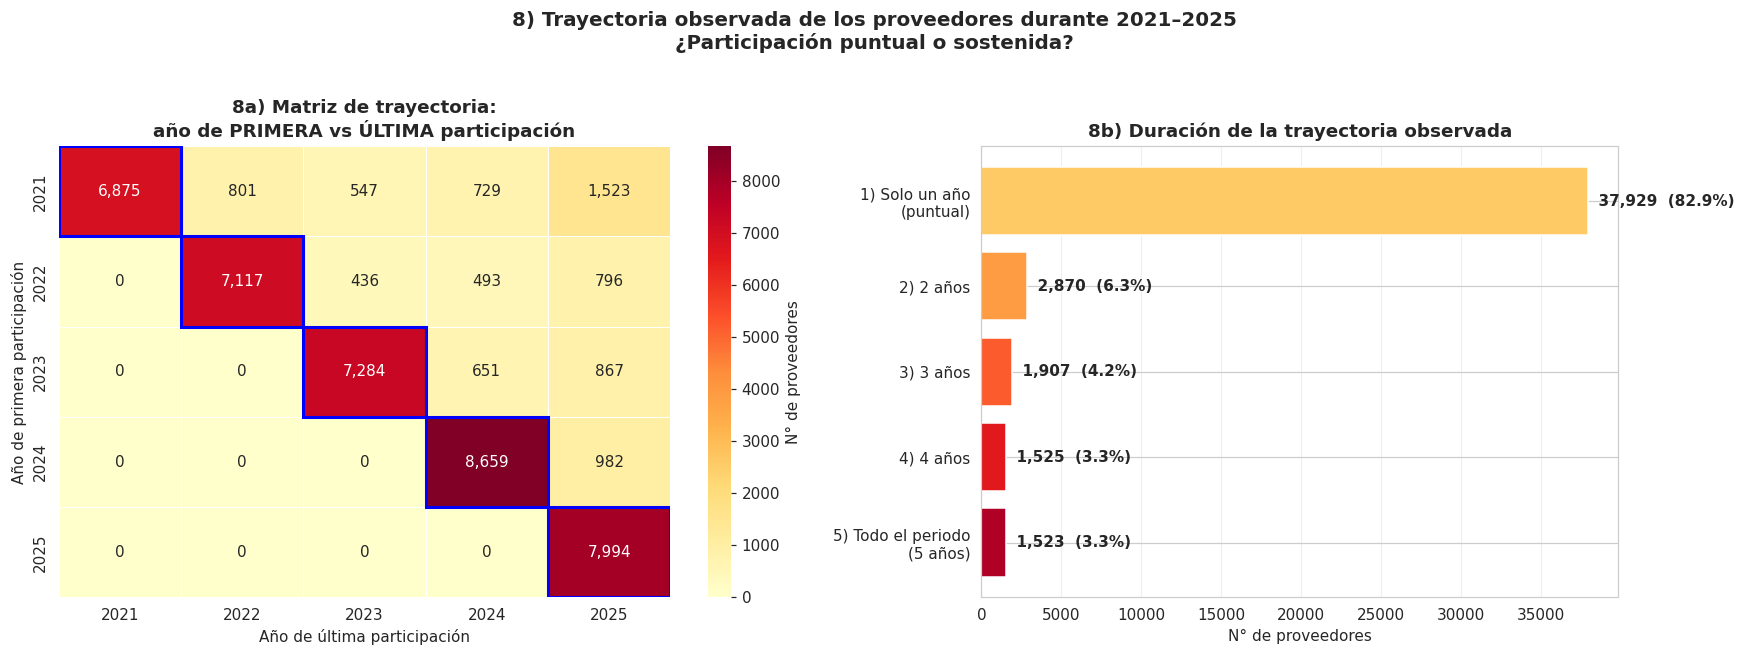


📊 Distribución de trayectorias:
  1) Solo un año (puntual)      :  37,929  ( 82.9%)
  2) 2 años                     :   2,870  (  6.3%)
  3) 3 años                     :   1,907  (  4.2%)
  4) 4 años                     :   1,525  (  3.3%)
  5) Todo el periodo (5 años)   :   1,523  (  3.3%)

💡 Hallazgos clave:
   • 82.9% de proveedores participó UN SOLO AÑO (participación puntual)
   • 3.3% de proveedores participó los 5 años (trayectoria sostenida)

📈 Entrantes al mercado por año (primera participación):
   2021: 10,475 proveedores nuevos
   2022:  8,842 proveedores nuevos
   2023:  8,802 proveedores nuevos
   2024:  9,641 proveedores nuevos
   2025:  7,994 proveedores nuevos


In [ ]:
# ============================================================
# 8) TRAYECTORIA OBSERVADA 2021–2025
#    Pregunta: ¿la participación de los proveedores es puntual
#              o sostenida a lo largo del periodo?
# ============================================================
df_proveedores['anio_primera'] = df_proveedores['primera_participacion'].dt.year
df_proveedores['anio_ultima']  = df_proveedores['ultima_participacion'].dt.year

d8 = df_proveedores.dropna(subset=['anio_primera', 'anio_ultima']).copy()
d8['anio_primera'] = d8['anio_primera'].astype(int)
d8['anio_ultima']  = d8['anio_ultima'].astype(int)

# --- panel 8a: matriz (primera vs última participación) ---
matriz = (d8.groupby(['anio_primera', 'anio_ultima'])['ruc_proveedor']
            .count()
            .reset_index()
            .pivot(index='anio_primera', columns='anio_ultima', values='ruc_proveedor')
            .fillna(0)
            .astype(int)
            .sort_index()
            .sort_index(axis=1))

# --- panel 8b: categorías de trayectoria ---
d8['anios_activo'] = d8['anio_ultima'] - d8['anio_primera']
def cat_tray(a):
    if a == 0: return '1) Solo un año\n(puntual)'
    if a == 1: return '2) 2 años'
    if a == 2: return '3) 3 años'
    if a == 3: return '4) 4 años'
    return '5) Todo el periodo\n(5 años)'
d8['trayectoria'] = d8['anios_activo'].apply(cat_tray)

conteo_tray = d8['trayectoria'].value_counts().sort_index()
pct_tray = conteo_tray / conteo_tray.sum() * 100

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8),
                         gridspec_kw={'width_ratios': [1.2, 1]})

# 8a) heatmap con anotaciones
sns.heatmap(matriz, annot=True, fmt=',d', cmap='YlOrRd',
            cbar_kws={'label': 'N° de proveedores'},
            linewidths=0.5, linecolor='white', ax=axes[0])
axes[0].set_title('8a) Matriz de trayectoria:\naño de PRIMERA vs ÚLTIMA participación',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Año de última participación')
axes[0].set_ylabel('Año de primera participación')

# resaltar diagonal (participación puntual = mismo año)
for i in range(min(matriz.shape)):
    axes[0].add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                     edgecolor='blue', lw=2))

# 8b) barra de categorías
colors_tray = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(conteo_tray)))
bars = axes[1].barh(conteo_tray.index, conteo_tray.values,
                    color=colors_tray, edgecolor='white')
for bar, pct in zip(bars, pct_tray):
    axes[1].text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                 f'  {int(bar.get_width()):,}  ({pct:.1f}%)',
                 va='center', fontsize=10, fontweight='bold')

axes[1].set_xlabel('N° de proveedores')
axes[1].set_title('8b) Duración de la trayectoria observada',
                  fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('8) Trayectoria observada de los proveedores durante 2021–2025\n'
             '¿Participación puntual o sostenida?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ---- resumen textual ----
print("\n📊 Distribución de trayectorias:")
for k, v in conteo_tray.items():
    print(f"  {k.replace(chr(10), ' '):30s}: {v:>7,}  ({v/conteo_tray.sum()*100:5.1f}%)")

puntual = conteo_tray.iloc[0]
sostenida = conteo_tray.iloc[-1] if len(conteo_tray) >= 5 else 0
total = conteo_tray.sum()

print(f"\n💡 Hallazgos clave:")
print(f"   • {puntual/total*100:.1f}% de proveedores participó UN SOLO AÑO (participación puntual)")
if sostenida > 0:
    print(f"   • {sostenida/total*100:.1f}% de proveedores participó los 5 años (trayectoria sostenida)")

# extra: entrantes por año
print(f"\n📈 Entrantes al mercado por año (primera participación):")
entrantes = d8['anio_primera'].value_counts().sort_index()
for anio, n in entrantes.items():
    print(f"   {anio}: {n:>6,} proveedores nuevos")

### Hallazgos — Trayectoria observada de los proveedores durante 2021–2025

El gráfico analiza la trayectoria temporal de participación de los proveedores, cruzando el año de su primera participación con el año de su última participación registrada. El panel 8a presenta la matriz completa de trayectorias, mientras que el panel 8b resume la duración de la trayectoria observada en cinco categorías.

**Panel 8a — Matriz de trayectoria (primera vs última participación):**

- La **diagonal principal** (recuadrada en azul) representa a los proveedores cuya primera y última participación coincide en el mismo año, es decir, con participación puntual. Concentra los valores más altos de toda la matriz: **6,875** proveedores solo en 2021, **7,117** en 2022, **7,284** en 2023, **8,659** en 2024 y **7,994** en 2025.

- Fuera de la diagonal, los valores caen drásticamente. Los proveedores presentes en todo el periodo (primera participación en 2021 y última en 2025) son solo **1,523**.

- Se observa además que **2024 concentra la mayor entrada de proveedores nuevos con participación puntual** (8,659), lo que sugiere un pico de incorporaciones al mercado durante ese año.

**Panel 8b — Duración de la trayectoria observada:**

- El **82.9% del padrón (37,929 proveedores)** presenta trayectoria puntual: aparece únicamente en un año del periodo analizado.

- Solo el **6.3% (2,870 proveedores)** tiene una trayectoria de 2 años.

- El **4.2% (1,907 proveedores)** presenta trayectoria de 3 años.

- El **3.3% (1,525 proveedores)** tiene trayectoria de 4 años.

- Únicamente el **3.3% (1,523 proveedores)** presenta trayectoria sostenida durante todo el periodo (5 años, de 2021 a 2025).

En conjunto, los proveedores con trayectoria de 3 o más años suman apenas **4,955 proveedores (10.8% del padrón)**, mientras que la enorme mayoría (**89.2%**) participa como máximo en dos años.

## Interpretación respecto al problema

Los resultados evidencian que la participación en contrataciones de municipalidades provinciales es **mayoritariamente puntual y no sostenida**. Ocho de cada diez proveedores del padrón aparecen solo un año en todo el periodo 2021–2025, lo que representa un mercado con **altísima rotación** y baja fidelización.

Este hallazgo tiene tres implicaciones importantes:

Primero, la **experiencia observada** no es una característica generalizada del padrón. Aunque el problema plantea la experiencia como una dimensión clave de heterogeneidad, en la práctica más del 82% de los proveedores no tiene experiencia recurrente en el mercado municipal. Solo un pequeño núcleo de aproximadamente **1,500 proveedores (3.3%)** ha participado de manera sostenida durante los cinco años, y por tanto constituye el grupo más maduro y consolidado del mercado.

Segundo, la matriz revela un patrón de **entradas y salidas constantes**. Cada año ingresan miles de proveedores nuevos que no vuelven a aparecer, lo que sugiere que el mercado funciona en gran medida como un canal de participación oportunista más que como un ecosistema empresarial consolidado. Esto es especialmente marcado en 2024, año con el mayor número de nuevos participantes puntuales (8,659), posiblemente asociado a cambios en normativa, incremento en convocatorias o dinámicas específicas de gestión municipal.

Tercero, la trayectoria temporal permite distinguir **al menos tres perfiles claramente diferenciados**:

- **Perfil puntual**: proveedores que aparecen solo en un año (82.9%), consistente con el perfil "ocasional local" identificado en el análisis de frecuencia y alcance territorial.
- **Perfil intermitente**: proveedores presentes en 2 a 4 años (13.8%), con participación irregular pero no sostenida.
- **Perfil sostenido**: proveedores presentes durante todo el periodo (3.3%), que representan el núcleo estable del mercado y probablemente coinciden con los proveedores de mayor escala económica y alcance territorial identificados en gráficos previos.

Por tanto, la trayectoria temporal constituye una variable relevante para la posterior identificación de segmentos naturales de proveedores, en tanto permite diferenciar perfiles de participación oportunista frente a perfiles con presencia sostenida y experiencia acumulada en el mercado de contrataciones municipales.



---

**6. Próximos pasos**

---




A partir de los hallazgos obtenidos en el análisis exploratorio, el siguiente paso será aplicar técnicas de **clustering** para identificar segmentos naturales de proveedores según sus patrones de participación y adjudicación.

**1. Selección y construcción de variables para la segmentación**

Se seleccionarán las variables que mejor representen las dimensiones principales del comportamiento de los proveedores: frecuencia de participación, número de adjudicaciones, tasa de adjudicación, monto total adjudicado, alcance territorial y participación en consorcios. Las variables de penalidades se mantendrán principalmente como variables de caracterización posterior, evitando que condicionen directamente la formación de los clusters.

**2. Transformación y estandarización de variables**

Debido a la elevada heterogeneidad observada en variables como número de convocatorias y montos adjudicados, se evaluará el uso de transformaciones logarítmicas para reducir el efecto de valores extremos. Posteriormente, las variables utilizadas en el clustering serán estandarizadas para evitar que las diferencias de escala determinen artificialmente la formación de los grupos.

**3. Determinación del número óptimo de clusters**

Se probarán diferentes valores de \(K\) mediante **K-Means**, comparando alternativas de segmentación. La elección del número de clusters se realizará considerando criterios estadísticos como el método del codo y el coeficiente de silueta, además de la interpretabilidad de los segmentos obtenidos.

**4. Construcción de los segmentos de proveedores**

Una vez seleccionado el número adecuado de clusters, se asignará cada proveedor a un segmento. Para cada grupo se calcularán estadísticas descriptivas de las principales variables, con el objetivo de identificar diferencias en frecuencia de participación, efectividad, monto adjudicado, alcance territorial y trayectoria.

**5. Perfilamiento e interpretación de los clusters**

Los clusters serán interpretados como perfiles de proveedores. Se buscará determinar, por ejemplo, si existen proveedores ocasionales con baja participación, proveedores recurrentes con alta efectividad, proveedores territorialmente diversificados y proveedores de gran escala económica. Estos perfiles serán contrastados con los hallazgos exploratorios obtenidos previamente.

**6. Validación y análisis de robustez**

Se verificará que los segmentos encontrados sean suficientemente diferenciados y que no estén determinados únicamente por valores extremos o por una sola variable. También se analizará la estabilidad de los resultados ante diferentes configuraciones de variables y parámetros.

**7. Caracterización final de los segmentos**

Finalmente, las variables que no hayan sido utilizadas para formar los clusters, como las penalidades, serán incorporadas para caracterizar los segmentos. Esto permitirá evaluar si determinados perfiles presentan mayores niveles de penalización, así como identificar comportamientos relevantes para la gestión y supervisión de las contrataciones municipales.

**8. Generación de conclusiones y recomendaciones**

Los resultados finales permitirán responder la pregunta de investigación, identificando los principales segmentos naturales de proveedores y las características que distinguen a cada uno. A partir de ello se formularán recomendaciones orientadas a mejorar la comprensión del comportamiento de los proveedores dentro del mercado de contrataciones municipales.

Se verificará que los segmentos encontrados sean suficientemente diferenciados y que no estén determinados únicamente por valores extremos o por una sola variable. También se analizará la estabilidad de los resultados ante diferentes configuraciones de variables y parámetros.
